# Image Classification with Convolutional Neural Network
### Sign Language Detection

## 1. Imports

In [ ]:
import os
import shutil
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import time
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam, SGD

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

## 2.5 PartA: Designing and Analyzing Convolutional Neural Networks from Scratch.

### 2.5.1 Data Understanding, Analysis, Visualization and Cleaning:

• What does the dataset represent? Provide a brief description.

The dataset represents Sign Language Dectection that contains images of hand gestures that represents sign language symbols.Each class represents different hand-sign letter. The task is a multi-class classification problem where the model should identify which sign is it representing in each image.

The dataset has 38 classes. Images were collected in different background with different hand configurations.

In [ ]:
from google.colab import drive
import zipfile

drive.mount('/content/drive', force_remount=True)

zip_path = '/content/drive/MyDrive/AI and ML/Sign Language Detection-20260427T163516Z-3-001.zip'

if os.path.exists(zip_path):
    print(f"File found. Size: {os.path.getsize(zip_path) / (1024**2):.2f} MB")
    try:
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall('dataset/')
        print("Extraction complete.")
    except zipfile.BadZipFile:
        print("Error: The file is not a valid zip file.")
else:
    print("Error: File path does not exist. Please check your Google Drive path.")

Mounted at /content/drive
File found. Size: 162.88 MB
Extraction complete.


## Remove Corrupt Images

### Create Train / Validation / Test Split (70% / 15% / 15%)



In [ ]:
source_path = "dataset/Sign Language Detection/Train"

bad_images = []
for root, dirs, files in os.walk(source_path):
    for file in files:
        path = os.path.join(root, file)
        try:
            img = Image.open(path)
            img.verify()
        except:
            bad_images.append(path)

print(f"Corrupt images found: {len(bad_images)}")
for img in bad_images:
    os.remove(img)
print("Corrupt images removed.")

Corrupt images found: 266
Corrupt images removed.


In [ ]:
SPLIT_DIR   = "dataset/split"
TRAIN_DIR   = os.path.join(SPLIT_DIR, "train")
VAL_DIR     = os.path.join(SPLIT_DIR, "val")
TEST_DIR    = os.path.join(SPLIT_DIR, "test")

TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15
# TEST_RATIO = remaining 15%

def create_split(source, train_dir, val_dir, test_dir,
                 train_ratio=0.70, val_ratio=0.15, seed=42):
    """Copy images from source into train/val/test folders."""
    random.seed(seed)
    classes = sorted(os.listdir(source))

    for cls in classes:
        cls_path = os.path.join(source, cls)
        if not os.path.isdir(cls_path):
            continue

        images = [f for f in os.listdir(cls_path)
                  if os.path.isfile(os.path.join(cls_path, f))]
        random.shuffle(images)

        n       = len(images)
        n_train = int(n * train_ratio)
        n_val   = int(n * val_ratio)

        splits = {
            train_dir: images[:n_train],
            val_dir:   images[n_train : n_train + n_val],
            test_dir:  images[n_train + n_val:]
        }

        for dest_root, file_list in splits.items():
            dest_cls = os.path.join(dest_root, cls)
            os.makedirs(dest_cls, exist_ok=True)
            for fname in file_list:
                shutil.copy(
                    os.path.join(cls_path, fname),
                    os.path.join(dest_cls, fname)
                )

    print(f"Split complete into: {train_dir}, {val_dir}, {test_dir}")


# Only run if not already split
if not os.path.exists(SPLIT_DIR):
    create_split(source_path, TRAIN_DIR, VAL_DIR, TEST_DIR)
else:
    print("Split directory already exists — skipping.")


# Verify counts
for split_name, split_dir in [("Train", TRAIN_DIR),
                               ("Val",   VAL_DIR),
                               ("Test",  TEST_DIR)]:
    total = sum(
        len(files)
        for _, _, files in os.walk(split_dir)
    )
    print(f"{split_name}: {total} images")

Split complete into: dataset/split/train, dataset/split/val, dataset/split/test
Train: 7536 images
Val: 1598 images
Test: 1658 images


In [ ]:
classes = os.listdir(TRAIN_DIR)
print("Classes:", classes)

Classes: ['14', '4', '10', '26', '25', '33', '6', '15', '11', '28', '37', '13', '9', '3', '0', '19', '20', '23', '36', '1', '22', '18', '30', '24', '29', '16', '27', '12', '21', '35', '17', '32', '2', '34', '7', '5', '31', '8']


• How many total images are in the dataset?

In [ ]:
total_images = 0

for cls in classes:
    class_path = os.path.join(TRAIN_DIR, cls)
    total_images += len(os.listdir(class_path))

print("Total Images in the dataset:", total_images)

Total Images in the dataset: 7536


• What is the distribution of images across different classes?

The bar chart shows the image count per classes and shows the distribition of images among the classes. Although the datset is approximately balanced, class 4 has less image.

Total Images = 7536
   Class  Images
0      0     200
1      1     200
2     10     203
3     11     198
4     12     193
5     13     195
6     14     189
7     15     200
8     16     203
9     17     200
10    18     200
11    19     201
12     2     203
13    20     200
14    21     200
15    22     205
16    23     199
17    24     203
18    25     200
19    26     199
20    27     200
21    28     198
22    29     199
23     3     195
24    30     199
25    31     201
26    32     196
27    33     201
28    34     198
29    35     195
30    36     197
31    37     202
32     4     167
33     5     200
34     6     198
35     7     197
36     8     203
37     9     199


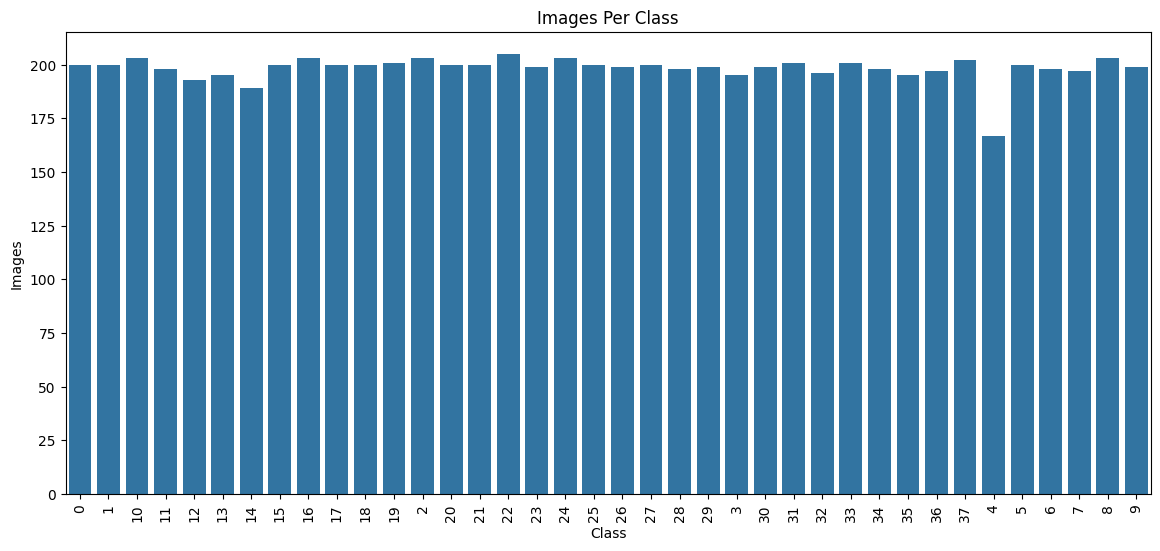

In [ ]:
classes = sorted(os.listdir(TRAIN_DIR))

total_images = 0
class_counts = {}

for cls in classes:
    folder = os.path.join(TRAIN_DIR, cls)
    count = len(os.listdir(folder))
    class_counts[cls] = count
    total_images += count

print("Total Images =", total_images)

df = pd.DataFrame(list(class_counts.items()), columns=["Class","Images"])
print(df)

# Plot Distribution
plt.figure(figsize=(14,6))
sns.barplot(x="Class", y="Images", data=df)
plt.xticks(rotation=90)
plt.title("Images Per Class")
plt.show()


• How is the dataset split into training and validation sets? Justify your choice.

The project uses Keras ImageDataGenerator's validation_split that split dataet into 80% training and 20% validation.
The 80/20 ratio is the standard industry choice as it provides enough data to learn meaningful patterns with reserving enough unseen samples for correct perfermance prediction.

• What preprocessing techniques (e.g., resizing, normalization) were applied?

Preprocessing techniques that were applied are :

1. Resizing
2. Normalization
3. Colour mode
4. Class mode

• What data generators, if any, were used for preprocessing and augmentation?

The data generators (ImageDataGenerator) that are used for prepossing and augmentation are:

1. tain_gen : applied to the training subset
2. val_gen : applied to the validation subset.

• If data augmentation was applied, provide visualizations of sample augmented images.

The data augmentation is only applied in the training dataset to reduce overfitting and to improve generalisations. Rotation and zoom is used for augmentation.

In [ ]:
IMG_SIZE   = (128, 128)
BATCH_SIZE = 32

train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=False
)

val_test_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=SEED
)

val_data = val_test_gen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_data = val_test_gen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

class_names = list(train_data.class_indices.keys())
num_classes = len(class_names)
print(f"Classes: {num_classes}")
print(f"Train batches: {len(train_data)}")
print(f"Val batches:   {len(val_data)}")
print(f"Test batches:  {len(test_data)}")

Found 7536 images belonging to 38 classes.
Found 1598 images belonging to 38 classes.
Found 1658 images belonging to 38 classes.
Classes: 38
Train batches: 236
Val batches:   50
Test batches:  52


## 7. Visualize Augmented Training Samples

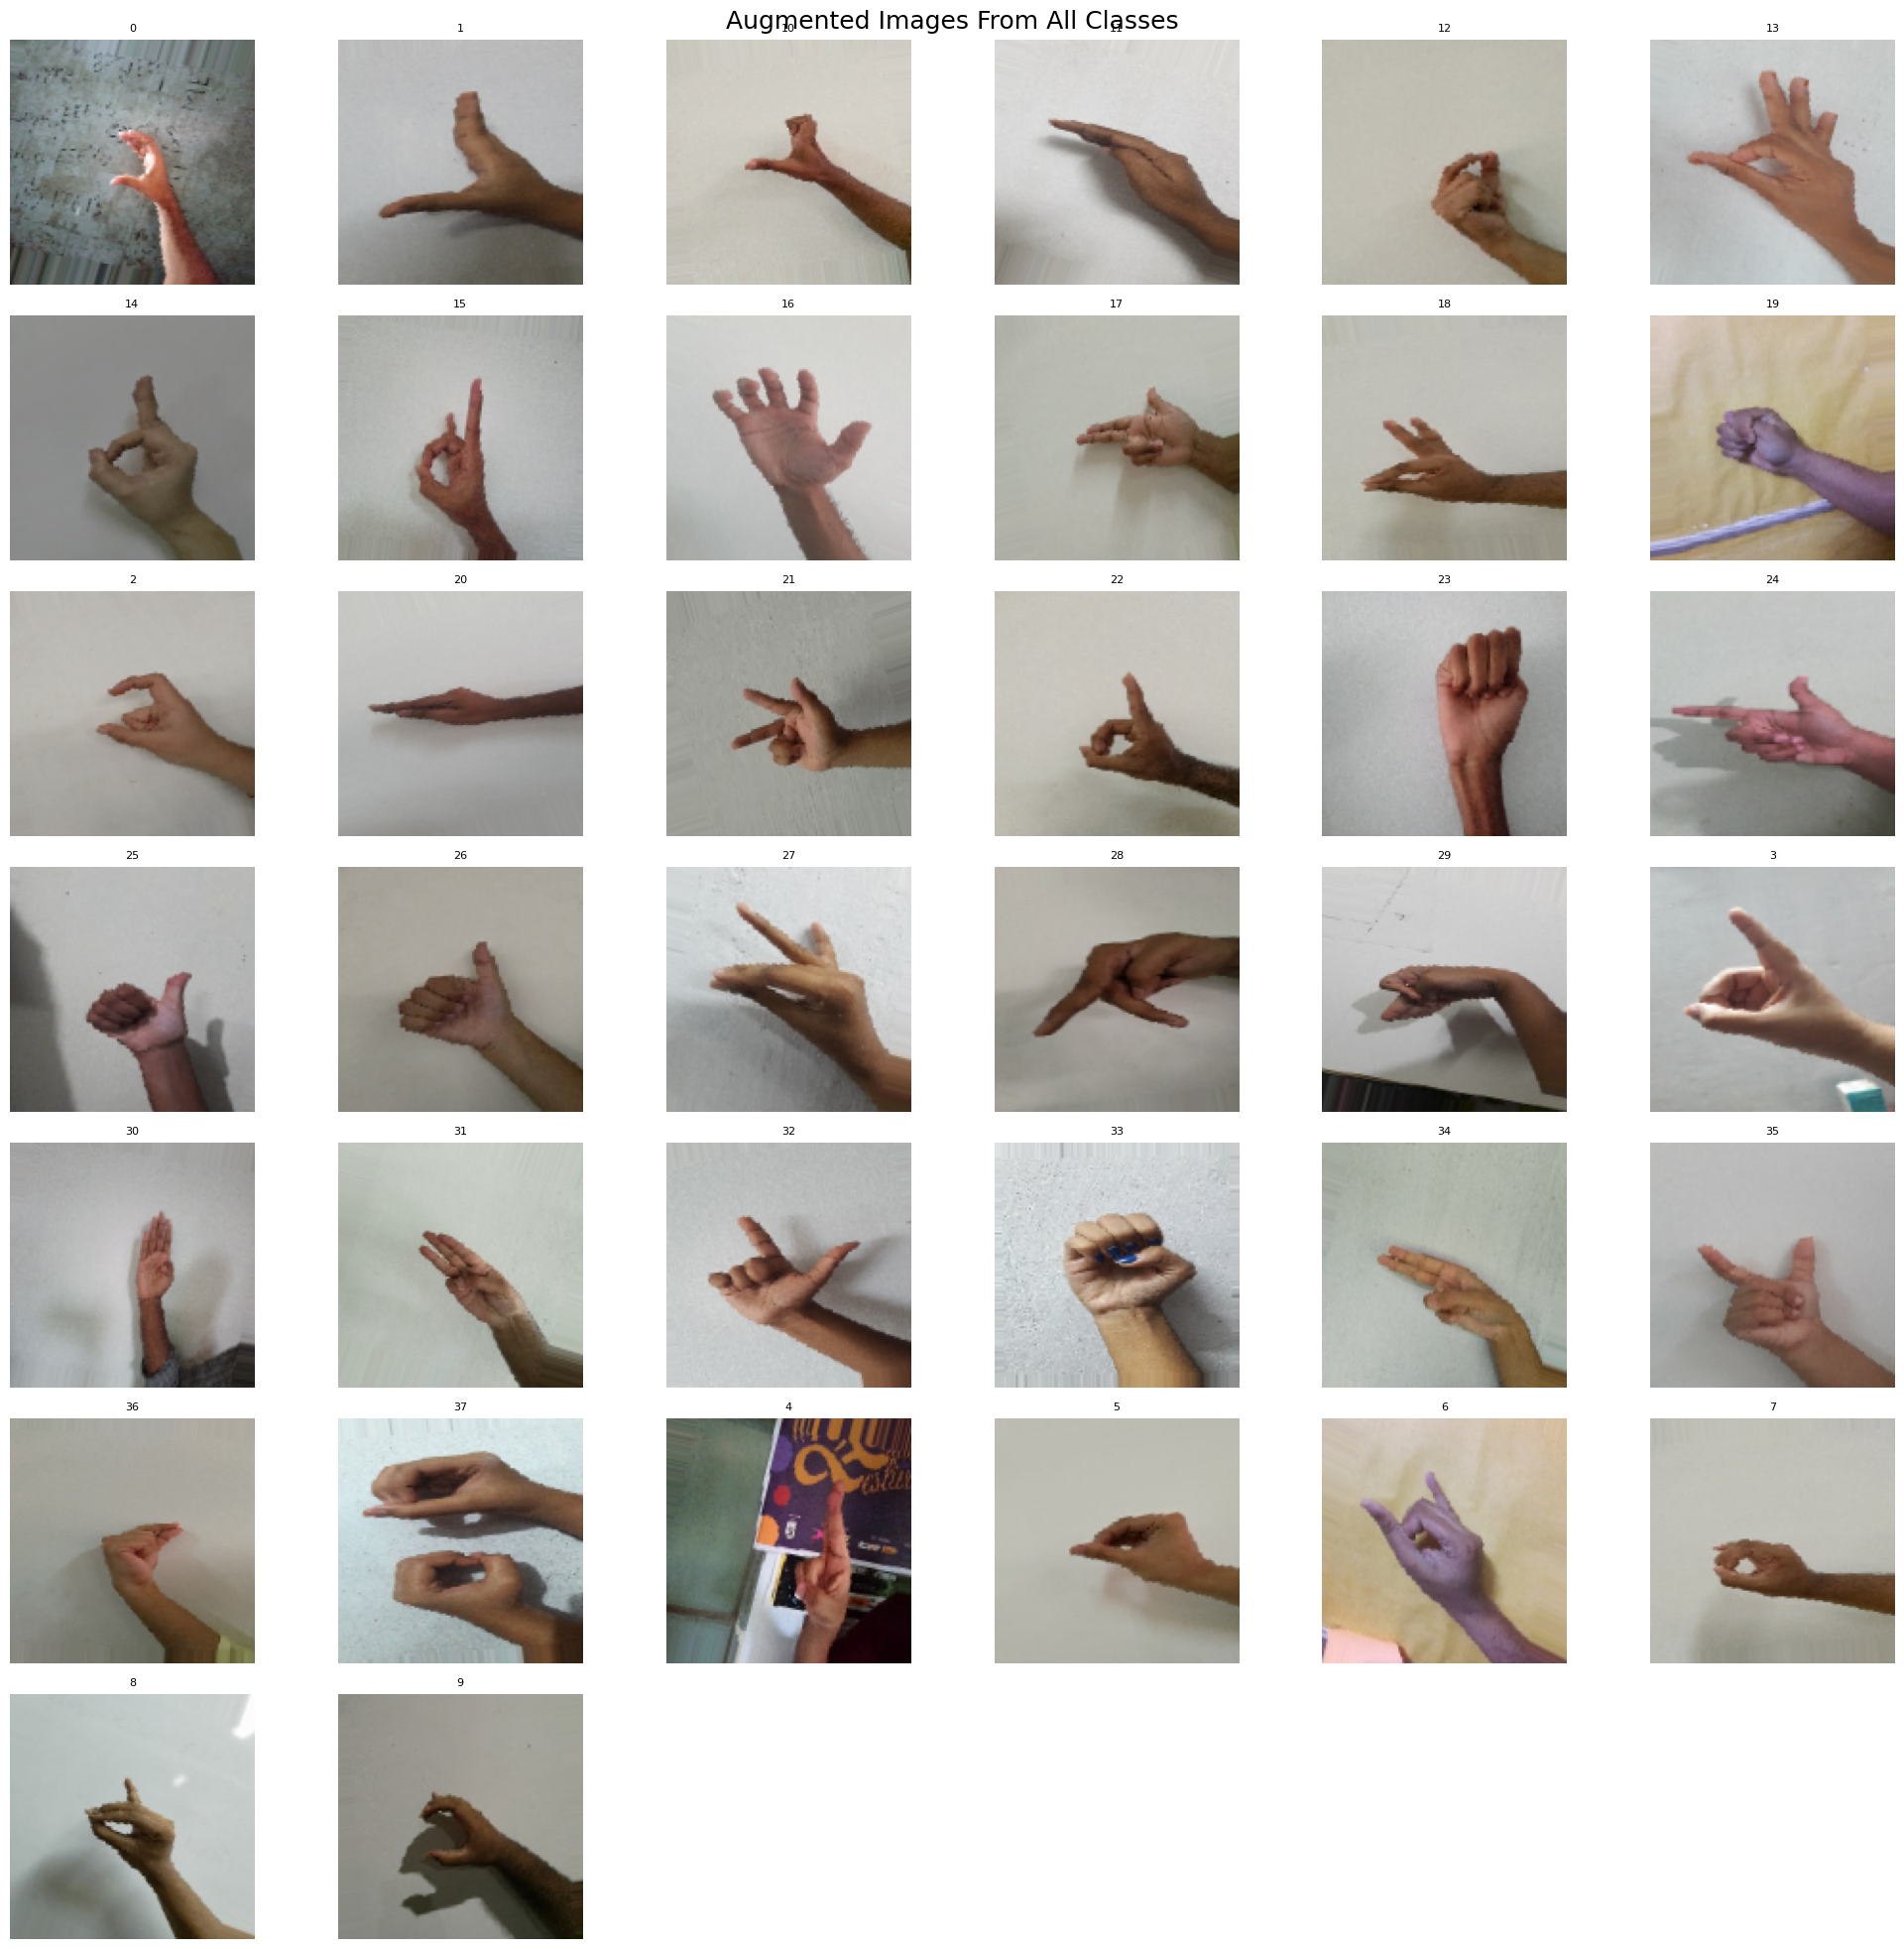

In [ ]:
train_data.reset()
class_samples = {}

while len(class_samples) < num_classes:
    images, labels = next(train_data)
    for i in range(len(images)):
        class_id = np.argmax(labels[i])
        if class_id not in class_samples:
            class_samples[class_id] = images[i]
        if len(class_samples) == num_classes:
            break

plt.figure(figsize=(20, 20))
for idx, class_id in enumerate(sorted(class_samples.keys())):
    plt.subplot(7, 6, idx + 1)
    plt.imshow(class_samples[class_id])
    plt.title(class_names[class_id], fontsize=8)
    plt.axis("off")
plt.suptitle("Augmented Images From All Classes", fontsize=18)
plt.tight_layout()
plt.show()

###  Evaluate on Test Set


In [ ]:
def evaluate_on_test(model, test_data, class_names, model_label="Model"):
    test_data.reset()
    preds   = model.predict(test_data, verbose=1)
    y_pred  = np.argmax(preds, axis=1)
    y_true  = test_data.classes

    loss, acc = model.evaluate(test_data, verbose=0)
    print(f"  TEST SET RESULTS — {model_label}")
    print(f"  Test Accuracy : {acc:.4f}")
    print(f"  Test Loss     : {loss:.4f}")

    print(classification_report(y_true, y_pred,
                                target_names=class_names, digits=4))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(18, 15))
    sns.heatmap(cm, fmt='d', annot=True, cmap="Blues")
    plt.title(f"Test Confusion Matrix — {model_label}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

    return acc, loss

## 2.5.2 Design, Train, and Evaluate a Baseline Model:

### 1. Model Architecture::

• Build a baseline CNN model with the following structure:

– Three Convolutional layers, each followed by pooling layers.

– Three fully connected layers (FCN)

– An output layer suitable for classification.

–Kernel Sizes

– Number of Filters

– Activation Functions

In [ ]:
model = models.Sequential([
    # Conv Block 1
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(128, 128, 3)),
    layers.MaxPooling2D((2,2)),

    # Conv Block 2
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    # Conv Block 3
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    # Flatten + FC
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),

    # Output
    layers.Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    12,845,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 38)             │         4,902 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,107,942 (50.00 MB)

 Trainable params: 13,107,942 (50.00 MB)

 Non-trainable params: 0 (0.00 B)

• Provide and Interpret the model summary.

The largest number of trainable parameters is present in the fully-connected layers, more specifically the initial Dense(512) layer following the conv output. Each MaxPooling operation reduces the feature map dimensions by half.

## 2. Model Training:

• Train the baseline model for an appropriate number of epochs.

In [ ]:
start = time.time()

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=20
)

training_time = time.time() - start
print(f"Baseline Training Time: {training_time:.2f} seconds")

Epoch 1/20
236/236 ━━━━━━━━━━━━━━━━━━━━ 52s 192ms/step - accuracy: 0.0681 - loss: 3.4843 - val_accuracy: 0.1533 - val_loss: 3.1188
Epoch 2/20
236/236 ━━━━━━━━━━━━━━━━━━━━ 43s 183ms/step - accuracy: 0.2661 - loss: 2.5971 - val_accuracy: 0.4180 - val_loss: 1.8409
Epoch 3/20
236/236 ━━━━━━━━━━━━━━━━━━━━ 40s 171ms/step - accuracy: 0.4752 - loss: 1.7109 - val_accuracy: 0.5357 - val_loss: 1.4357
Epoch 4/20
236/236 ━━━━━━━━━━━━━━━━━━━━ 40s 171ms/step - accuracy: 0.5888 - loss: 1.2986 - val_accuracy: 0.6214 - val_loss: 1.1589
Epoch 5/20
236/236 ━━━━━━━━━━━━━━━━━━━━ 40s 171ms/step - accuracy: 0.6618 - loss: 1.0503 - val_accuracy: 0.6640 - val_loss: 1.0897
Epoch 6/20
236/236 ━━━━━━━━━━━━━━━━━━━━ 38s 163ms/step - accuracy: 0.7067 - loss: 0.8978 - val_accuracy: 0.7053 - val_loss: 0.9739
Epoch 7/20
236/236 ━━━━━━━━━━━━━━━━━━━━ 39s 167ms/step - accuracy: 0.7452 - loss: 0.7984 - val_accuracy: 0.7403 - val_loss: 0.8741
Epoch 8/20
236/236 ━━━━━━━━━━━━━━━━━━━━ 40s 168ms/step - accuracy: 0.7702 - loss: 0

### 9.3 Training Curves

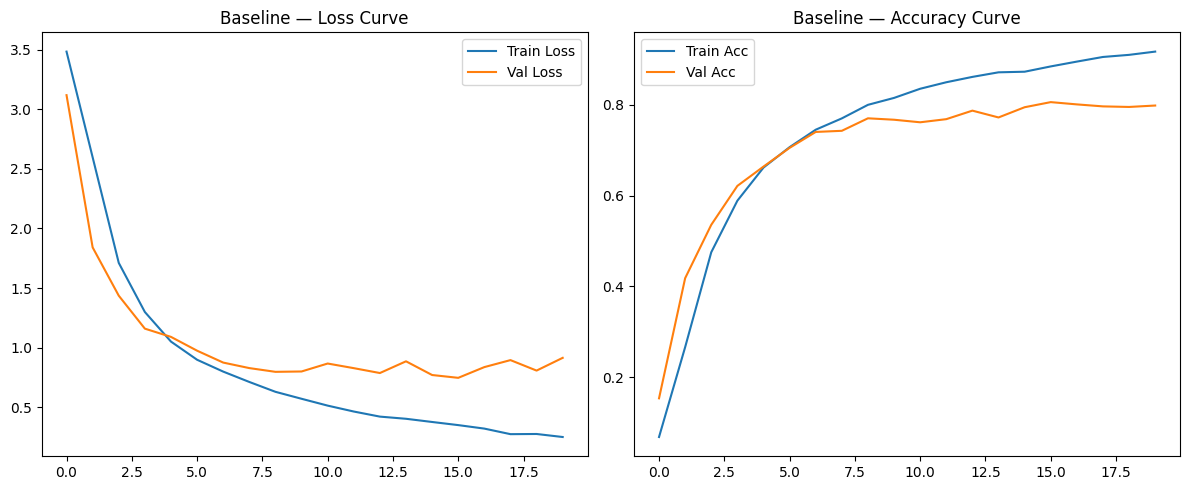

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'],     label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Baseline — Loss Curve")

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'],     label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.title("Baseline — Accuracy Curve")

plt.tight_layout()
plt.show()

### 3. Model Evaluation:

Evaluate the model using appropriate metrics (e.g. accuracy, precision, recall and F-1 score).

50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step
              precision    recall  f1-score   support

           0     0.8529    0.6905    0.7632        42
           1     0.8605    0.8605    0.8605        43
          10     0.8684    0.7674    0.8148        43
          11     0.9697    0.7619    0.8533        42
          12     0.7447    0.8537    0.7955        41
          13     0.6410    0.6098    0.6250        41
          14     0.6087    0.7000    0.6512        40
          15     0.7429    0.6047    0.6667        43
          16     0.9722    0.8140    0.8861        43
          17     0.8780    0.8571    0.8675        42
          18     0.5833    0.8140    0.6796        43
          19     0.8108    0.6977    0.7500        43
           2     0.8837    0.8837    0.8837        43
          20     0.8000    0.8571    0.8276        42
          21     0.7917    0.9048    0.8444        42
          22     0.7447    0.8140    0.7778        43
          23     0.7333    0.5238    0.61

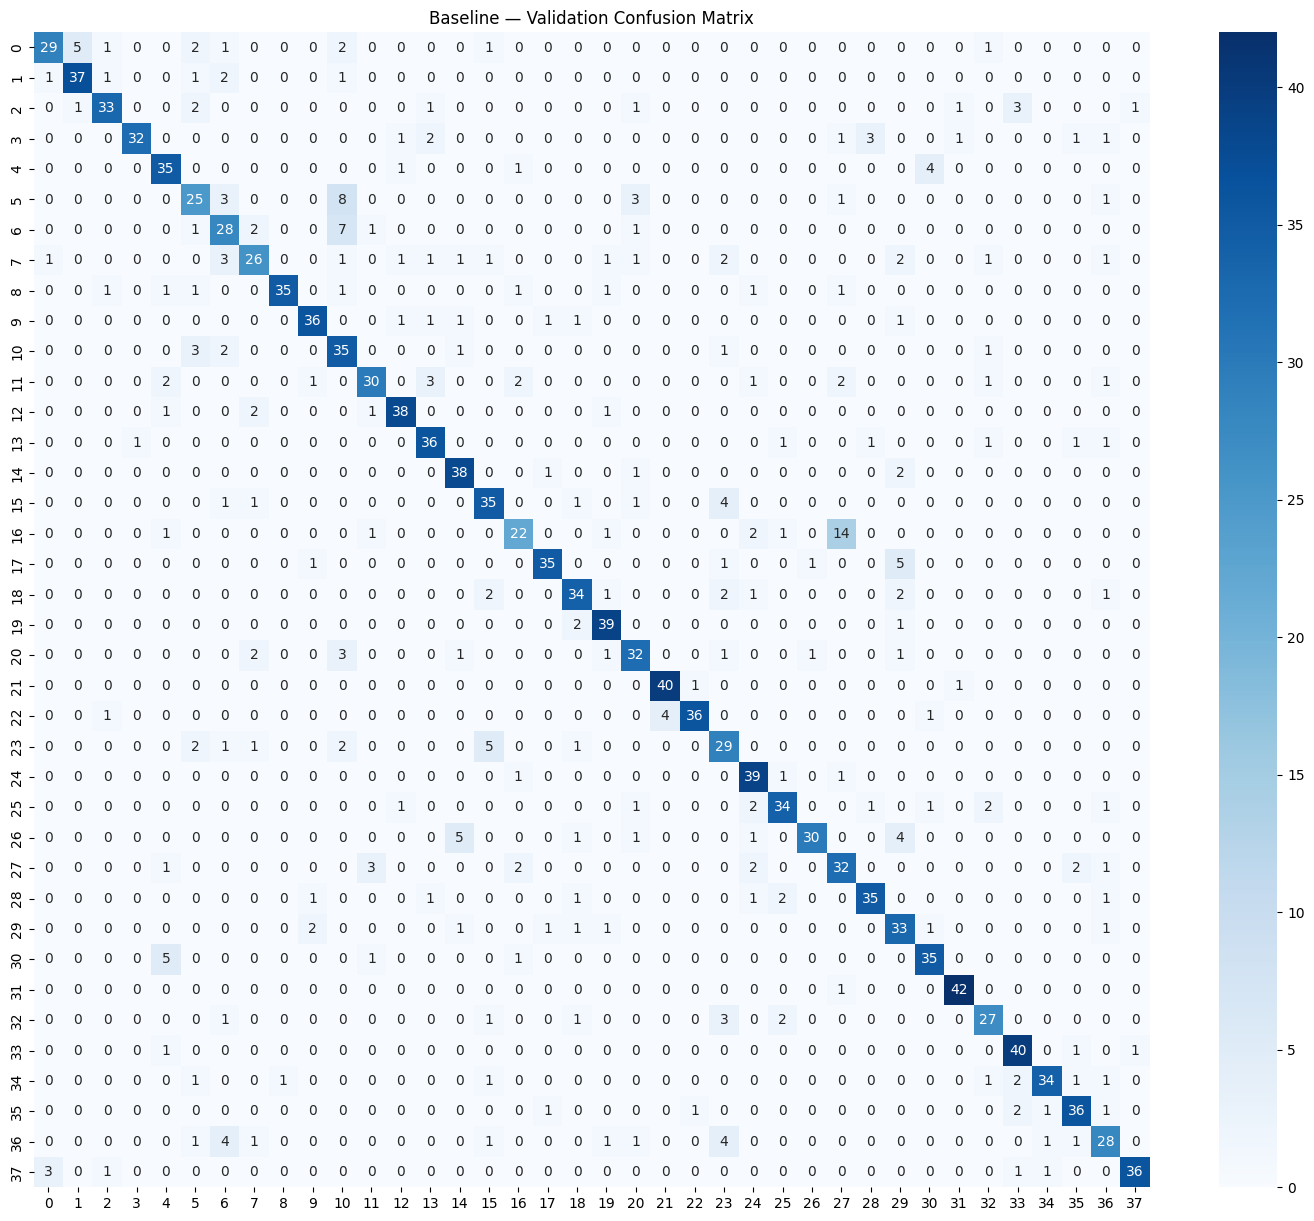

In [ ]:
val_data.reset()
pred   = model.predict(val_data)
y_pred = np.argmax(pred, axis=1)
y_true = val_data.classes

print(classification_report(y_true, y_pred,
                             target_names=class_names, digits=4))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(18, 15))
sns.heatmap(cm, fmt='d', annot=True, cmap="Blues")
plt.title("Baseline — Validation Confusion Matrix")
plt.show()

baseline_val_acc = max(history.history['val_accuracy'])

52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step
  TEST SET RESULTS — Baseline CNN
  Test Accuracy : 0.7871
  Test Loss     : 0.8816
              precision    recall  f1-score   support

           0     0.8611    0.7045    0.7750        44
           1     0.9070    0.8864    0.8966        44
          10     0.8600    0.9556    0.9053        45
          11     0.9118    0.7045    0.7949        44
          12     0.6140    0.8140    0.7000        43
          13     0.7561    0.7209    0.7381        43
          14     0.6905    0.7073    0.6988        41
          15     0.7347    0.8182    0.7742        44
          16     0.9714    0.7556    0.8500        45
          17     0.9487    0.8409    0.8916        44
          18     0.6154    0.7273    0.6667        44
          19     0.6275    0.7273    0.6737        44
           2     0.9512    0.8667    0.9070        45
          20     0.8889    0.7273    0.8000        44
          21     0.8000    0.9091    0.8511        44
          2

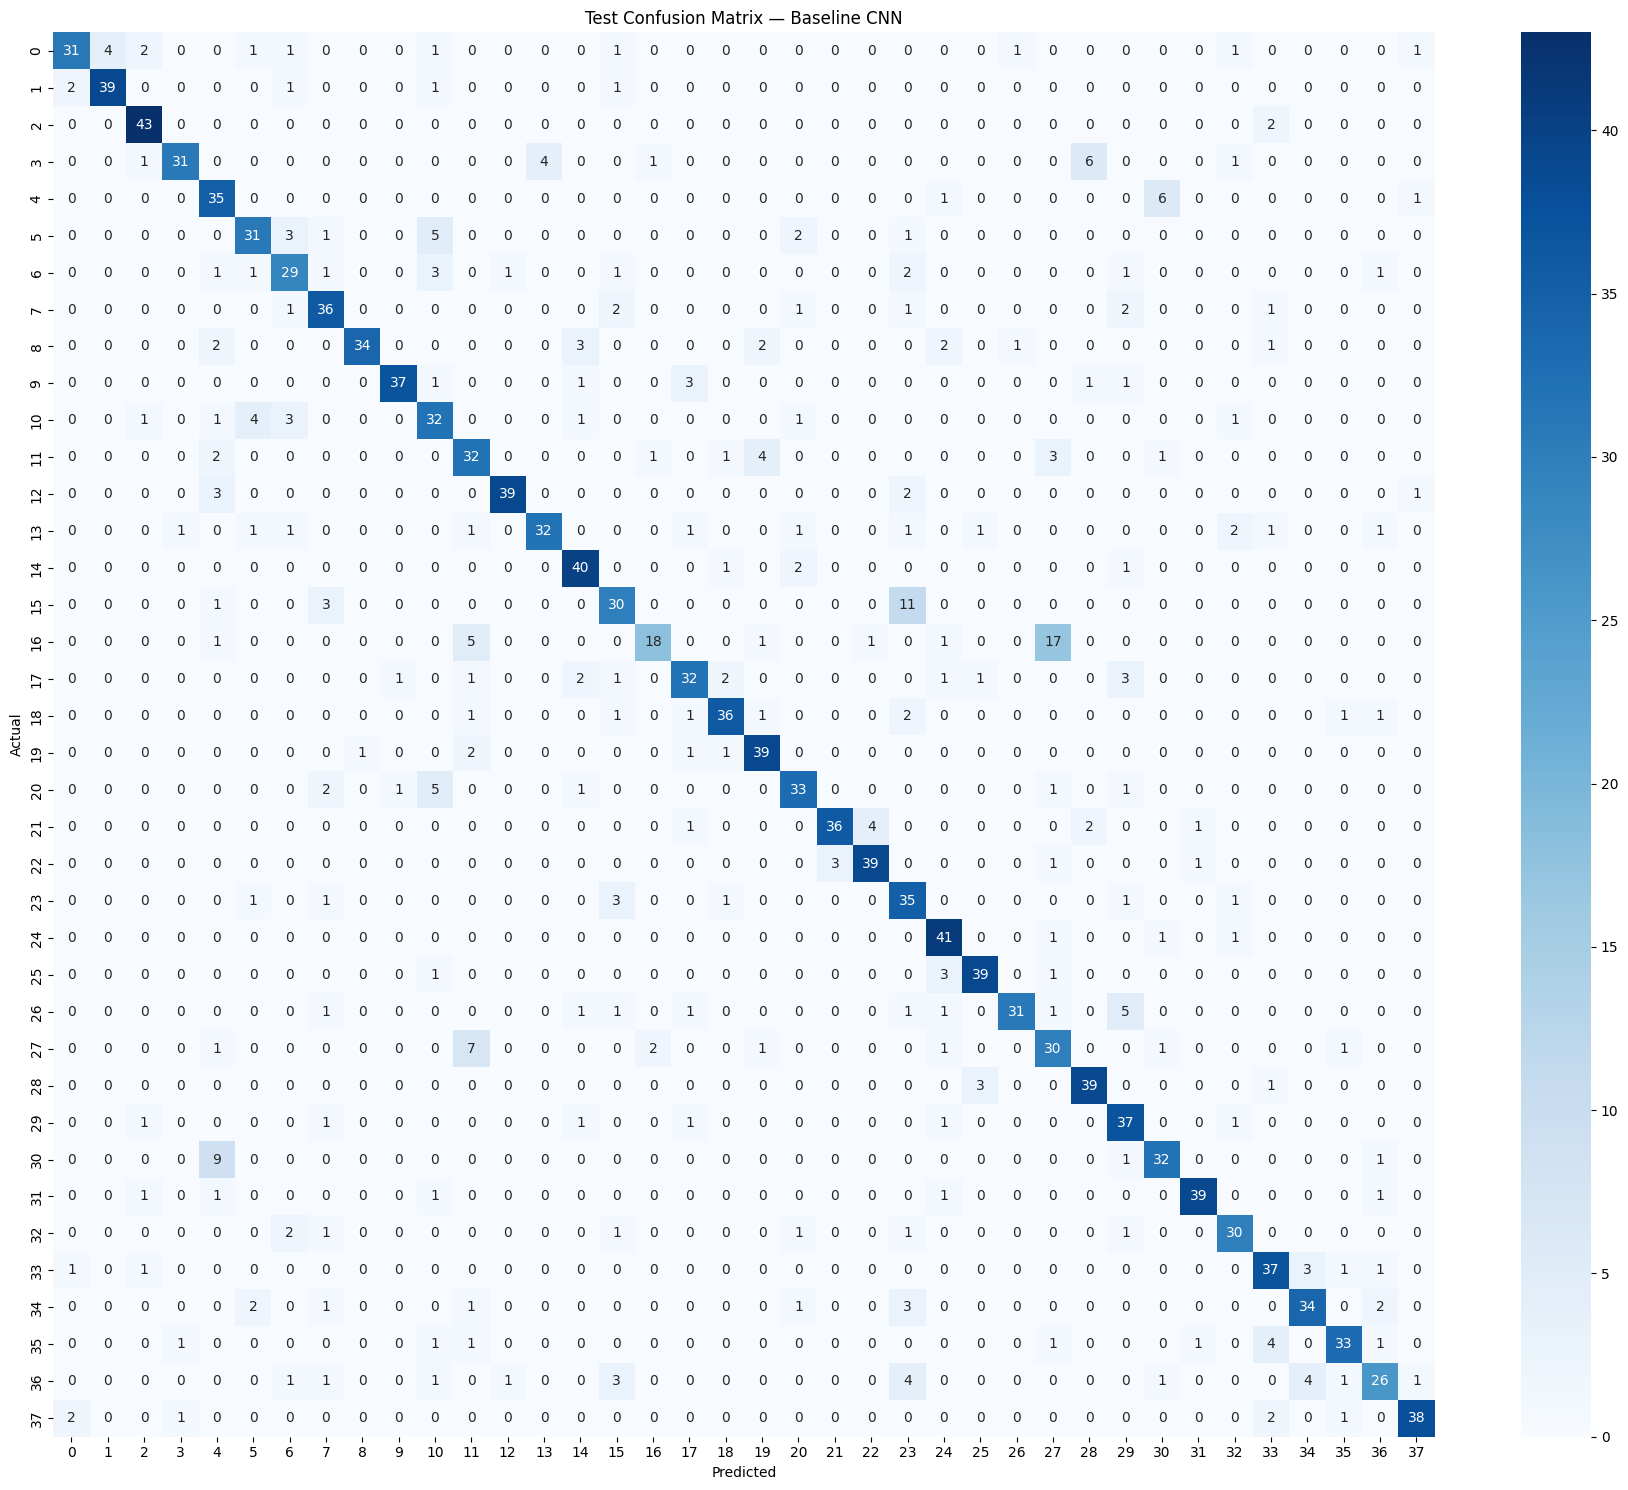

In [ ]:
baseline_test_acc, baseline_test_loss = evaluate_on_test(
    model, test_data, class_names, model_label="Baseline CNN"
)

• Perform inference on sample images and plot the result.


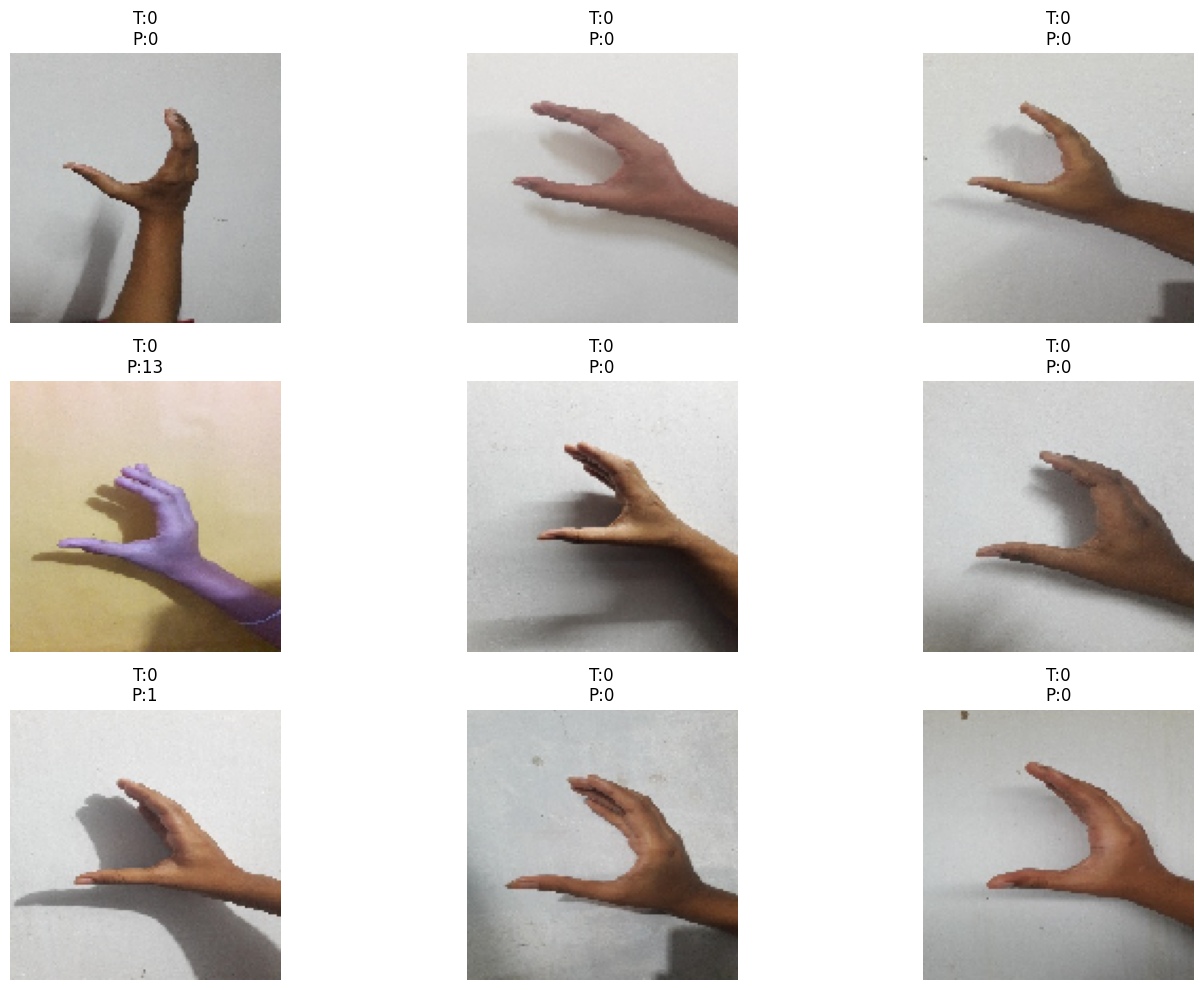

In [ ]:
test_data.reset()
images, labels = next(test_data)

plt.figure(figsize=(15, 10))
for i in range(9):
    img        = images[i]
    true_label = class_names[np.argmax(labels[i])]
    pred_class = np.argmax(model.predict(np.expand_dims(img, 0), verbose=0))
    pred_label = class_names[pred_class]
    plt.subplot(3, 3, i + 1)
    plt.imshow(img)
    plt.title(f"T:{true_label}\nP:{pred_label}")
    plt.axis("off")
plt.tight_layout()
plt.show()

• Discuss key observations about model performance.

- Convergence
- Overfitting risk
- Moderate Accuracy
- Inference Speed

### 2.5.3 Deeper Architecture with Regularization Layer:

#### 1. Model Architecture:

• Extend the baseline model by modifying the number of filters and layers to build deeper architec
ture{at least double the layer in comparison to baseline model}.

• Extend the layers introducing the following regularization techniques.

The deeper model doubles the number of convolutional blocks (4 blocks vs 3) and doubles filters at each stage. Regularization techniques added are :

1. Batch Normalisation
2. Dropout
3. L2 Weight Decay
4. Early Stopping
5. ReduceLROnPlateau


In [ ]:
deep_model = models.Sequential([

    layers.Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(128,128,3)),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    layers.Conv2D(128, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3,3), padding='same', activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.30),

    layers.Conv2D(256, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(256, (3,3), padding='same', activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.30),

    layers.Flatten(),
    layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.Dropout(0.30),
    layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.Dropout(0.25),
    layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.001)),

    layers.Dense(num_classes, activation='softmax')
])

deep_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

deep_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │     8,389,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             

 Total params: 9,732,422 (37.13 MB)

 Trainable params: 9,731,462 (37.12 MB)

 Non-trainable params: 960 (3.75 KB)

• Print and analyze the new model summary.


- Many more parameters compared to the baseline model, particularly coming from the Block 4 layer filters (256 filters × large spatial maps).

- Each batch normalization layer provides a modest increase in trainable parameters (scale γ and shift β per channel).

- Overall, the model has 3-5 times the number of parameters of the baseline, hence the extra computation time needed.

#### 2. Model Training:

• Train the deeper model for an appropriate number of epochs.

In [ ]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6)
]

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_data.classes),
    y=train_data.classes
)
class_weight_dict = dict(enumerate(class_weights))

start = time.time()

history_deep = deep_model.fit(
    train_data,
    validation_data=val_data,
    epochs=30,
    callbacks=callbacks,
    class_weight=class_weight_dict
)

deep_training_time = time.time() - start
print(f"Deep Model Training Time: {deep_training_time:.2f} seconds")

Epoch 1/30
236/236 ━━━━━━━━━━━━━━━━━━━━ 49s 208ms/step - accuracy: 0.6383 - loss: 1.6598 - val_accuracy: 0.7647 - val_loss: 1.2889 - learning_rate: 0.0010
Epoch 2/30
236/236 ━━━━━━━━━━━━━━━━━━━━ 45s 189ms/step - accuracy: 0.6700 - loss: 1.5817 - val_accuracy: 0.7528 - val_loss: 1.3126 - learning_rate: 0.0010
Epoch 3/30
236/236 ━━━━━━━━━━━━━━━━━━━━ 42s 177ms/step - accuracy: 0.6864 - loss: 1.5252 - val_accuracy: 0.7703 - val_loss: 1.2652 - learning_rate: 0.0010
Epoch 4/30
236/236 ━━━━━━━━━━━━━━━━━━━━ 42s 179ms/step - accuracy: 0.7115 - loss: 1.4416 - val_accuracy: 0.7897 - val_loss: 1.1910 - learning_rate: 0.0010
Epoch 5/30
236/236 ━━━━━━━━━━━━━━━━━━━━ 42s 177ms/step - accuracy: 0.7175 - loss: 1.3942 - val_accuracy: 0.7954 - val_loss: 1.1717 - learning_rate: 0.0010
Epoch 6/30
236/236 ━━━━━━━━━━━━━━━━━━━━ 42s 179ms/step - accuracy: 0.7448 - loss: 1.3272 - val_accuracy: 0.7879 - val_loss: 1.1764 - learning_rate: 0.0010
Epoch 7/30
236/236 ━━━━━━━━━━━━━━━━━━━━ 42s 177ms/step - accuracy: 0.7

• Compare its training time and loss curves against the baseline model.

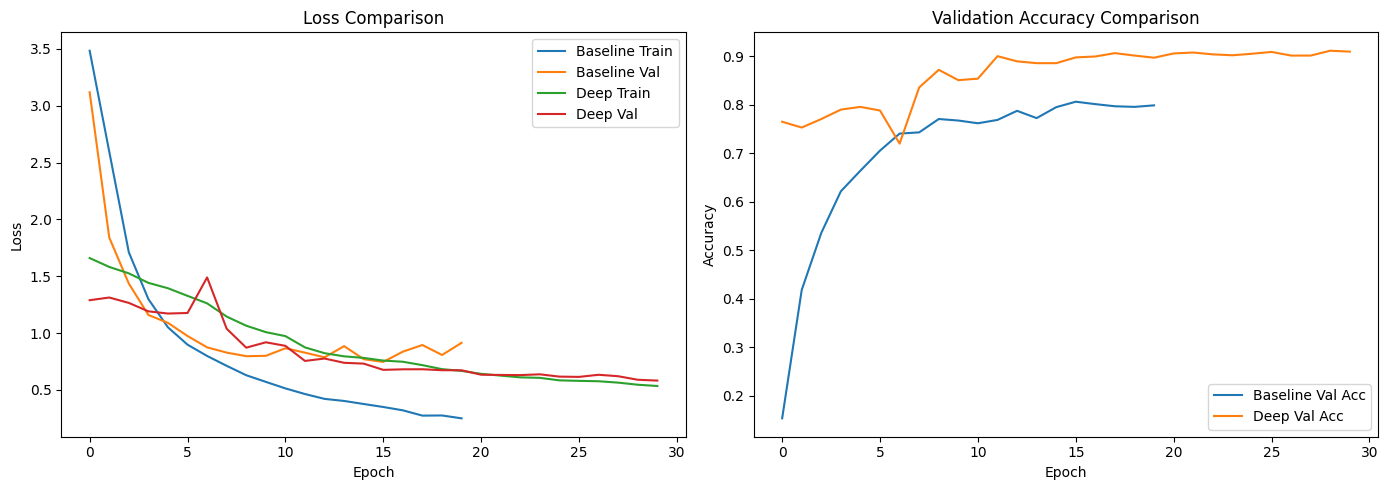

In [ ]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'],          label='Baseline Train')
plt.plot(history.history['val_loss'],      label='Baseline Val')
plt.plot(history_deep.history['loss'],     label='Deep Train')
plt.plot(history_deep.history['val_loss'], label='Deep Val')
plt.title("Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['val_accuracy'],      label='Baseline Val Acc')
plt.plot(history_deep.history['val_accuracy'], label='Deep Val Acc')
plt.title("Validation Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

deep_val_acc = max(history_deep.history['val_accuracy'])

#### 3. Model Evaluation:

• Evaluate the deeper model on the same performance metrics as the baseline model.

52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step
  TEST SET RESULTS — Deep CNN (Adam)
  Test Accuracy : 0.9168
  Test Loss     : 0.5858
              precision    recall  f1-score   support

           0     0.8913    0.9318    0.9111        44
           1     0.9091    0.9091    0.9091        44
          10     0.9778    0.9778    0.9778        45
          11     0.9545    0.9545    0.9545        44
          12     0.8723    0.9535    0.9111        43
          13     0.9524    0.9302    0.9412        43
          14     0.8947    0.8293    0.8608        41
          15     0.9744    0.8636    0.9157        44
          16     0.9762    0.9111    0.9425        45
          17     0.9535    0.9318    0.9425        44
          18     0.8750    0.7955    0.8333        44
          19     0.8780    0.8182    0.8471        44
           2     0.9773    0.9556    0.9663        45
          20     0.9318    0.9318    0.9318        44
          21     0.9773    0.9773    0.9773        44
        

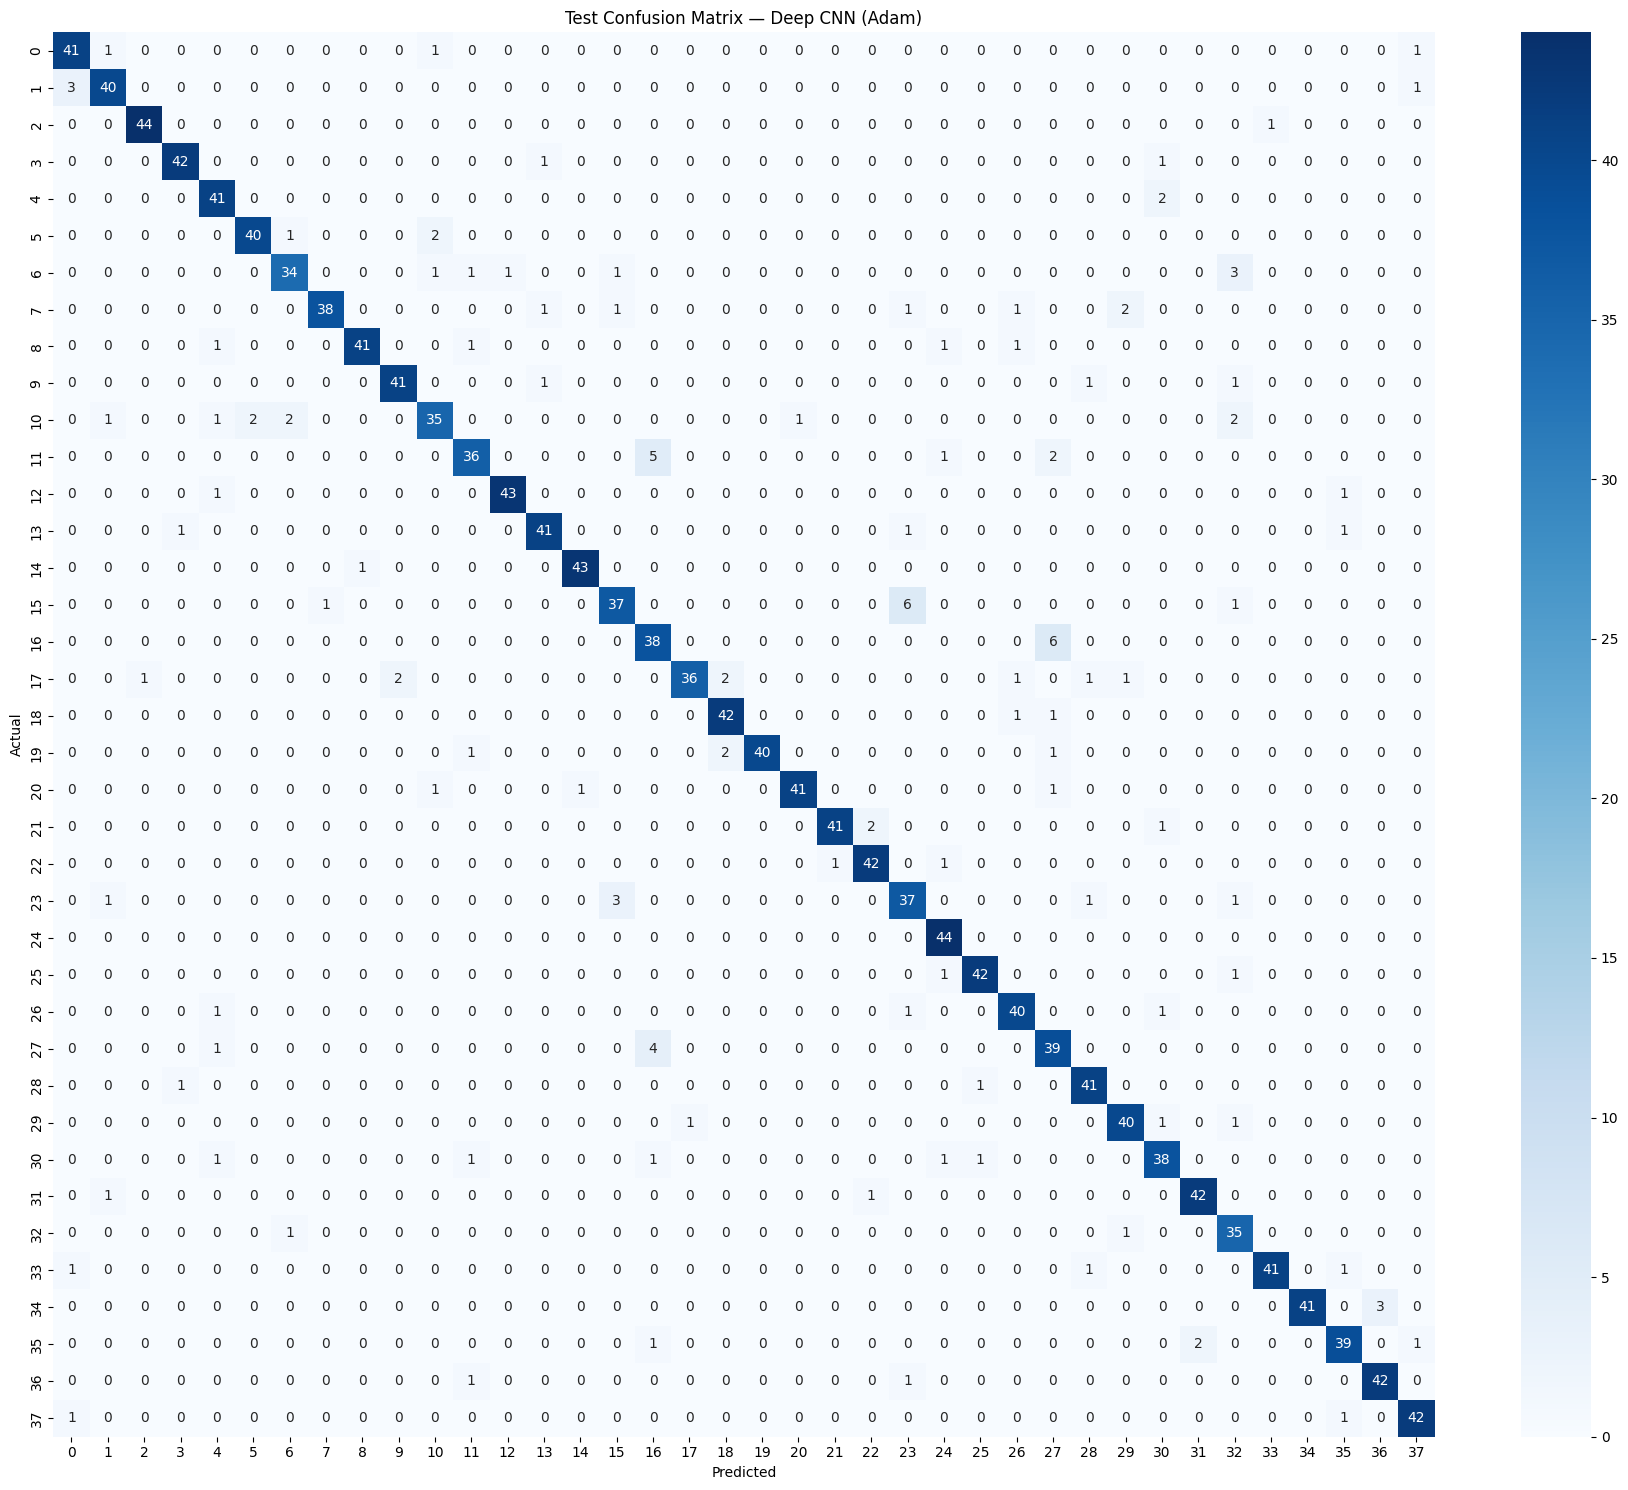

In [ ]:
deep_test_acc, deep_test_loss = evaluate_on_test(
    deep_model, test_data, class_names, model_label="Deep CNN (Adam)"
)

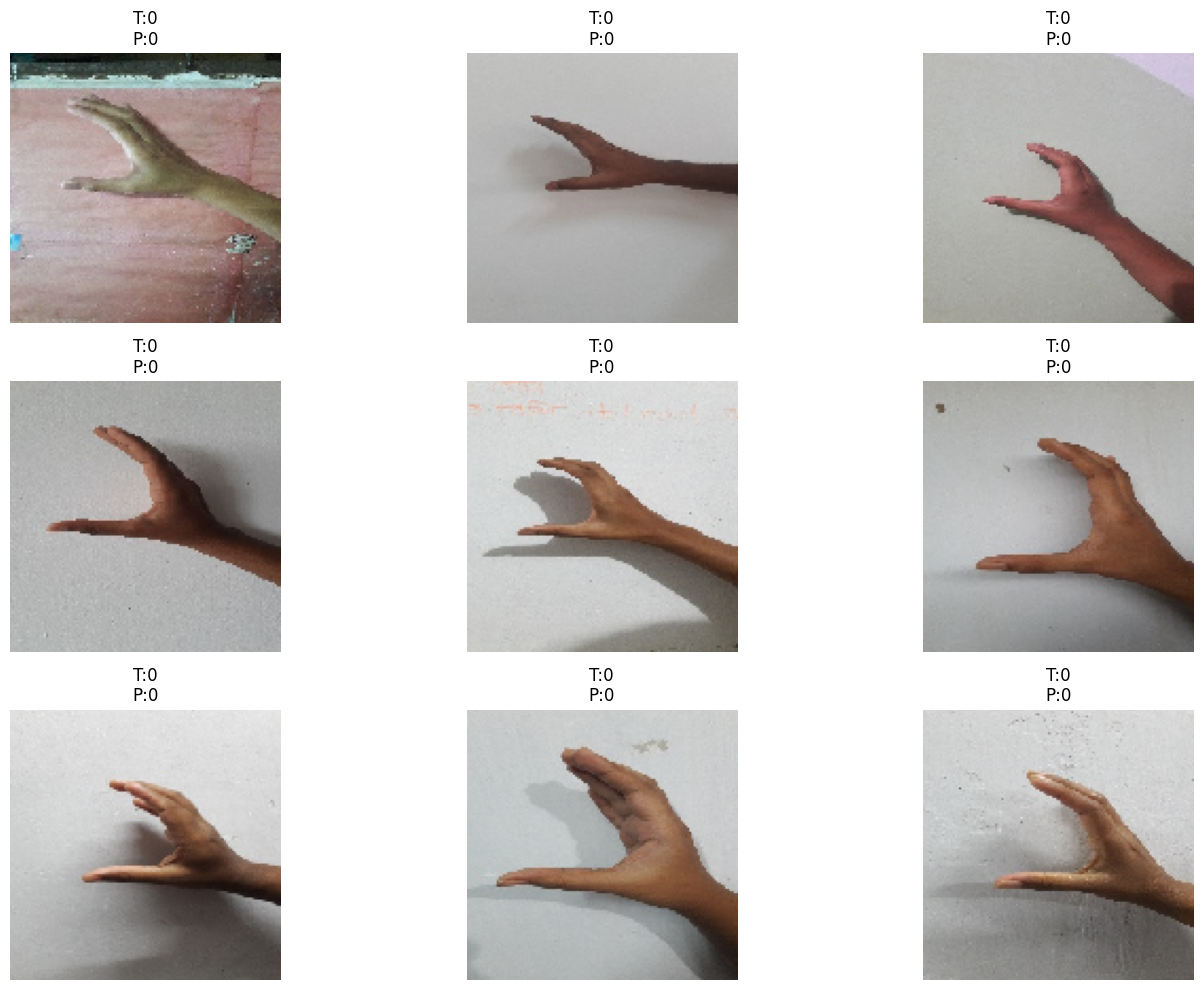

In [ ]:
images, labels = next(val_data)

plt.figure(figsize=(15,10))

for i in range(9):

    img = images[i]
    true_label = class_names[np.argmax(labels[i])]

    pred_img = np.expand_dims(img, axis=0)
    pred_class = np.argmax(deep_model.predict(pred_img, verbose=0))
    pred_label = class_names[pred_class]

    plt.subplot(3,3,i+1)
    plt.imshow(img)
    plt.title(f"T:{true_label}\nP:{pred_label}")
    plt.axis("off")

plt.tight_layout()
plt.show()

• Discuss improvements (or lack thereof) compared to the baseline model

The improvements compared to the baseline model are :

1. Improved generalisation
2. Smoother loss curve
3. Earlier convergence
4. Higher validation accuracy
5. Training time increase

### 2.5.4 Experimentation and Comparative Analysis:

#### 1. Baseline vs. Deeper Model Performance:

• Compare classification accuracy, loss, and evaluation metrics.

In [ ]:
print(f"{'Model':<20} {'Test Accuracy':>12} {'Test Loss':>10}")
print(f"{'Baseline CNN':<20} {baseline_test_acc:>12.4f} {baseline_test_loss:>10.4f}")
print(f"{'Deep CNN (Adam)':<20} {deep_test_acc:>12.4f} {deep_test_loss:>10.4f}")

Model                Test Accuracy  Test Loss
Baseline CNN               0.7871     0.8816
Deep CNN (Adam)            0.9168     0.5858


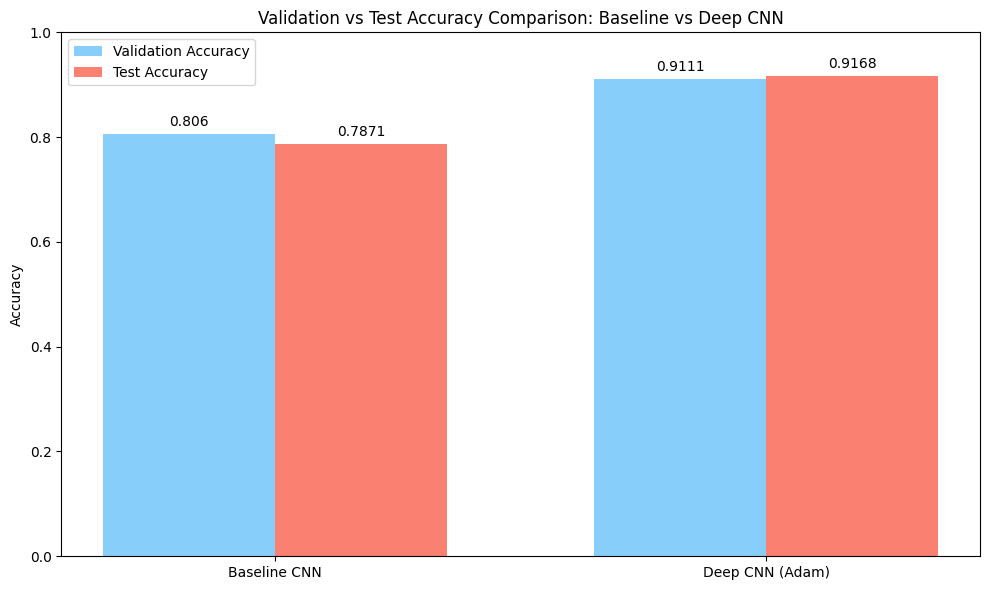

In [ ]:
model_labels = ['Baseline CNN', 'Deep CNN (Adam)']
val_accuracies = [baseline_val_acc, deep_val_acc]
test_accuracies = [baseline_test_acc, deep_test_acc]

x = np.arange(len(model_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

bars1 = ax.bar(x - width/2, val_accuracies, width, label='Validation Accuracy', color='lightskyblue')
bars2 = ax.bar(x + width/2, test_accuracies, width, label='Test Accuracy', color='salmon')

ax.set_ylabel('Accuracy')
ax.set_title('Validation vs Test Accuracy Comparison: Baseline vs Deep CNN')
ax.set_xticks(x)
ax.set_xticklabels(model_labels)
ax.set_ylim(0, 1.0)
ax.legend()

for bar in bars1:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 0.01, round(yval, 4), ha='center', va='bottom')
for bar in bars2:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 0.01, round(yval, 4), ha='center', va='bottom')

plt.tight_layout()
plt.show()

• Discuss whether adding more layers and filters improved performance.

Adding more layers and filters improves the performace.
The deeper architecture attains better validation accuracy due to:
1. Extra convolution layers that generate more abstract, discriminating features.
2. Avoidance of memorization through regularisation.
3. High effective learning rates due to batch normalization.

#### 2. Computational Efficiency:

• Compare training time and computational cost of the two models.

In [ ]:
print("TRAINING TIME")

baseline_training_time = training_time

print(f"Baseline Training Time: {baseline_training_time:.2f} sec")
print(f"Deep Model Training Time: {deep_training_time:.2f} sec")

TRAINING TIME
Baseline Training Time: 850.79 sec
Deep Model Training Time: 1319.03 sec


• Discuss the trade- offs between model complexity and efficiency.

Trade-offs between model complexity and effeciency:

1. Training for the deep model is 2–4 times slower due to an increase in the number of parameters as well as the extra pass performed per layer.
2. Batch Normalization creates additional computation per epoch but may result in fewer epochs overall by facilitating quicker convergence.
3. On the other hand, for use on edge devices (such as mobile sign language apps), the basic model might be favored even though its performance is poorer – a common compromise between accuracy and latency.
4. Using Google Colab with a T4 GPU speeds up training compared to using a CPU only.

### 3. Optimizer Analysis: SGD vs Adam:

• Train the deeper model with SGD and then Adam.

In [ ]:
deep_model_sgd = tf.keras.models.clone_model(deep_model)

deep_model_sgd.compile(
    optimizer=SGD(learning_rate=0.01, momentum=0.9),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

start = time.time()

history_sgd = deep_model_sgd.fit(
    train_data,
    validation_data=val_data,
    epochs=30
)

sgd_training_time = time.time() - start
print(f"SGD Training Time: {sgd_training_time:.2f} seconds")

Epoch 1/30
236/236 ━━━━━━━━━━━━━━━━━━━━ 68s 237ms/step - accuracy: 0.0405 - loss: 5.1497 - val_accuracy: 0.0319 - val_loss: 5.0401
Epoch 2/30
236/236 ━━━━━━━━━━━━━━━━━━━━ 43s 181ms/step - accuracy: 0.0689 - loss: 4.8457 - val_accuracy: 0.0895 - val_loss: 4.7326
Epoch 3/30
236/236 ━━━━━━━━━━━━━━━━━━━━ 44s 184ms/step - accuracy: 0.0874 - loss: 4.5965 - val_accuracy: 0.0951 - val_loss: 4.5119
Epoch 4/30
236/236 ━━━━━━━━━━━━━━━━━━━━ 43s 181ms/step - accuracy: 0.1153 - loss: 4.3277 - val_accuracy: 0.1508 - val_loss: 4.0727
Epoch 5/30
236/236 ━━━━━━━━━━━━━━━━━━━━ 43s 180ms/step - accuracy: 0.1652 - loss: 3.9384 - val_accuracy: 0.2522 - val_loss: 3.5319
Epoch 6/30
236/236 ━━━━━━━━━━━━━━━━━━━━ 43s 181ms/step - accuracy: 0.2237 - loss: 3.5724 - val_accuracy: 0.2728 - val_loss: 3.3745
Epoch 7/30
236/236 ━━━━━━━━━━━━━━━━━━━━ 43s 181ms/step - accuracy: 0.2752 - loss: 3.2448 - val_accuracy: 0.3492 - val_loss: 3.0938
Epoch 8/30
236/236 ━━━━━━━━━━━━━━━━━━━━ 43s 181ms/step - accuracy: 0.3388 - loss: 2

In [ ]:
deep_acc = max(history_deep.history['val_accuracy'])
print(f"Deep Model Accuracy: {deep_acc:.4f}")

deep_model_sdg_acc=max(history_sgd.history['val_accuracy'])
print(f"Deep Model SGD Accuracy: {deep_model_sdg_acc:.4f}")

Deep Model Accuracy: 0.9111
Deep Model SGD Accuracy: 0.8661


• Compare the impact of these optimizers on convergence speed and final performance.

The convergence speed is slow in SGD and faster in adam as well as the accuracy is slightly lower in SGD than Adam.

- Adam employs adaptive learning rates for each parameter based on first and second moments, which make it better equipped to handle sparse and complex data such as image sign recognition.
- SGD may sometimes generalise better for very large data sets, but learning rates must be carefully adjusted.
- For sign language classification (38 classes), involving complex hand gestures, Adam usually provides superior performance in fewer epochs.

#### Optimizer Comparison Plot

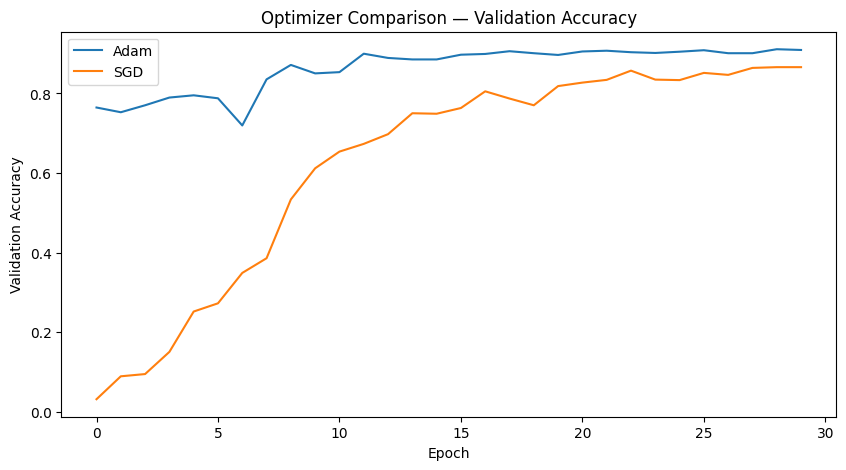

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(history_deep.history['val_accuracy'], label='Adam')
plt.plot(history_sgd.history['val_accuracy'],  label='SGD')
plt.title("Optimizer Comparison — Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.show()

sgd_val_acc = max(history_sgd.history['val_accuracy'])

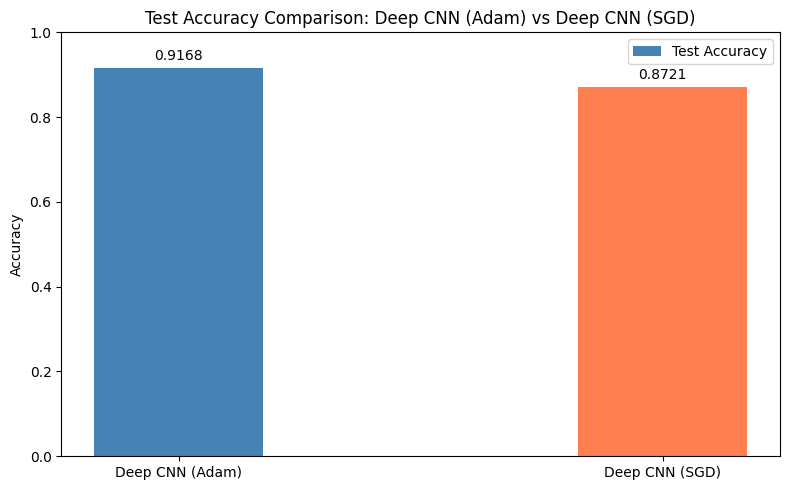

In [ ]:
model_labels = ['Deep CNN (Adam)', 'Deep CNN (SGD)']
test_accuracies = [deep_test_acc, sgd_test_acc]

x = np.arange(len(model_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(x, test_accuracies, width, label='Test Accuracy', color=['steelblue', 'coral'])

ax.set_ylabel('Accuracy')
ax.set_title('Test Accuracy Comparison: Deep CNN (Adam) vs Deep CNN (SGD)')
ax.set_xticks(x)
ax.set_xticklabels(model_labels)
ax.set_ylim(0, 1.0)
ax.legend()

for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 0.01, round(yval, 4), ha='center', va='bottom')

plt.tight_layout()
plt.show()

####Test Set Evaluation — Deep Model (SGD)

52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step
  TEST SET RESULTS — Deep CNN (SGD)
  Test Accuracy : 0.8721
  Test Loss     : 0.9738
              precision    recall  f1-score   support

           0     0.8163    0.9091    0.8602        44
           1     0.8723    0.9318    0.9011        44
          10     0.8980    0.9778    0.9362        45
          11     0.9730    0.8182    0.8889        44
          12     0.9444    0.7907    0.8608        43
          13     0.9167    0.7674    0.8354        43
          14     0.8919    0.8049    0.8462        41
          15     0.9474    0.8182    0.8780        44
          16     1.0000    0.7778    0.8750        45
          17     0.9348    0.9773    0.9556        44
          18     0.8293    0.7727    0.8000        44
          19     0.9048    0.8636    0.8837        44
           2     0.9318    0.9111    0.9213        45
          20     0.8478    0.8864    0.8667        44
          21     0.9070    0.8864    0.8966        44
         

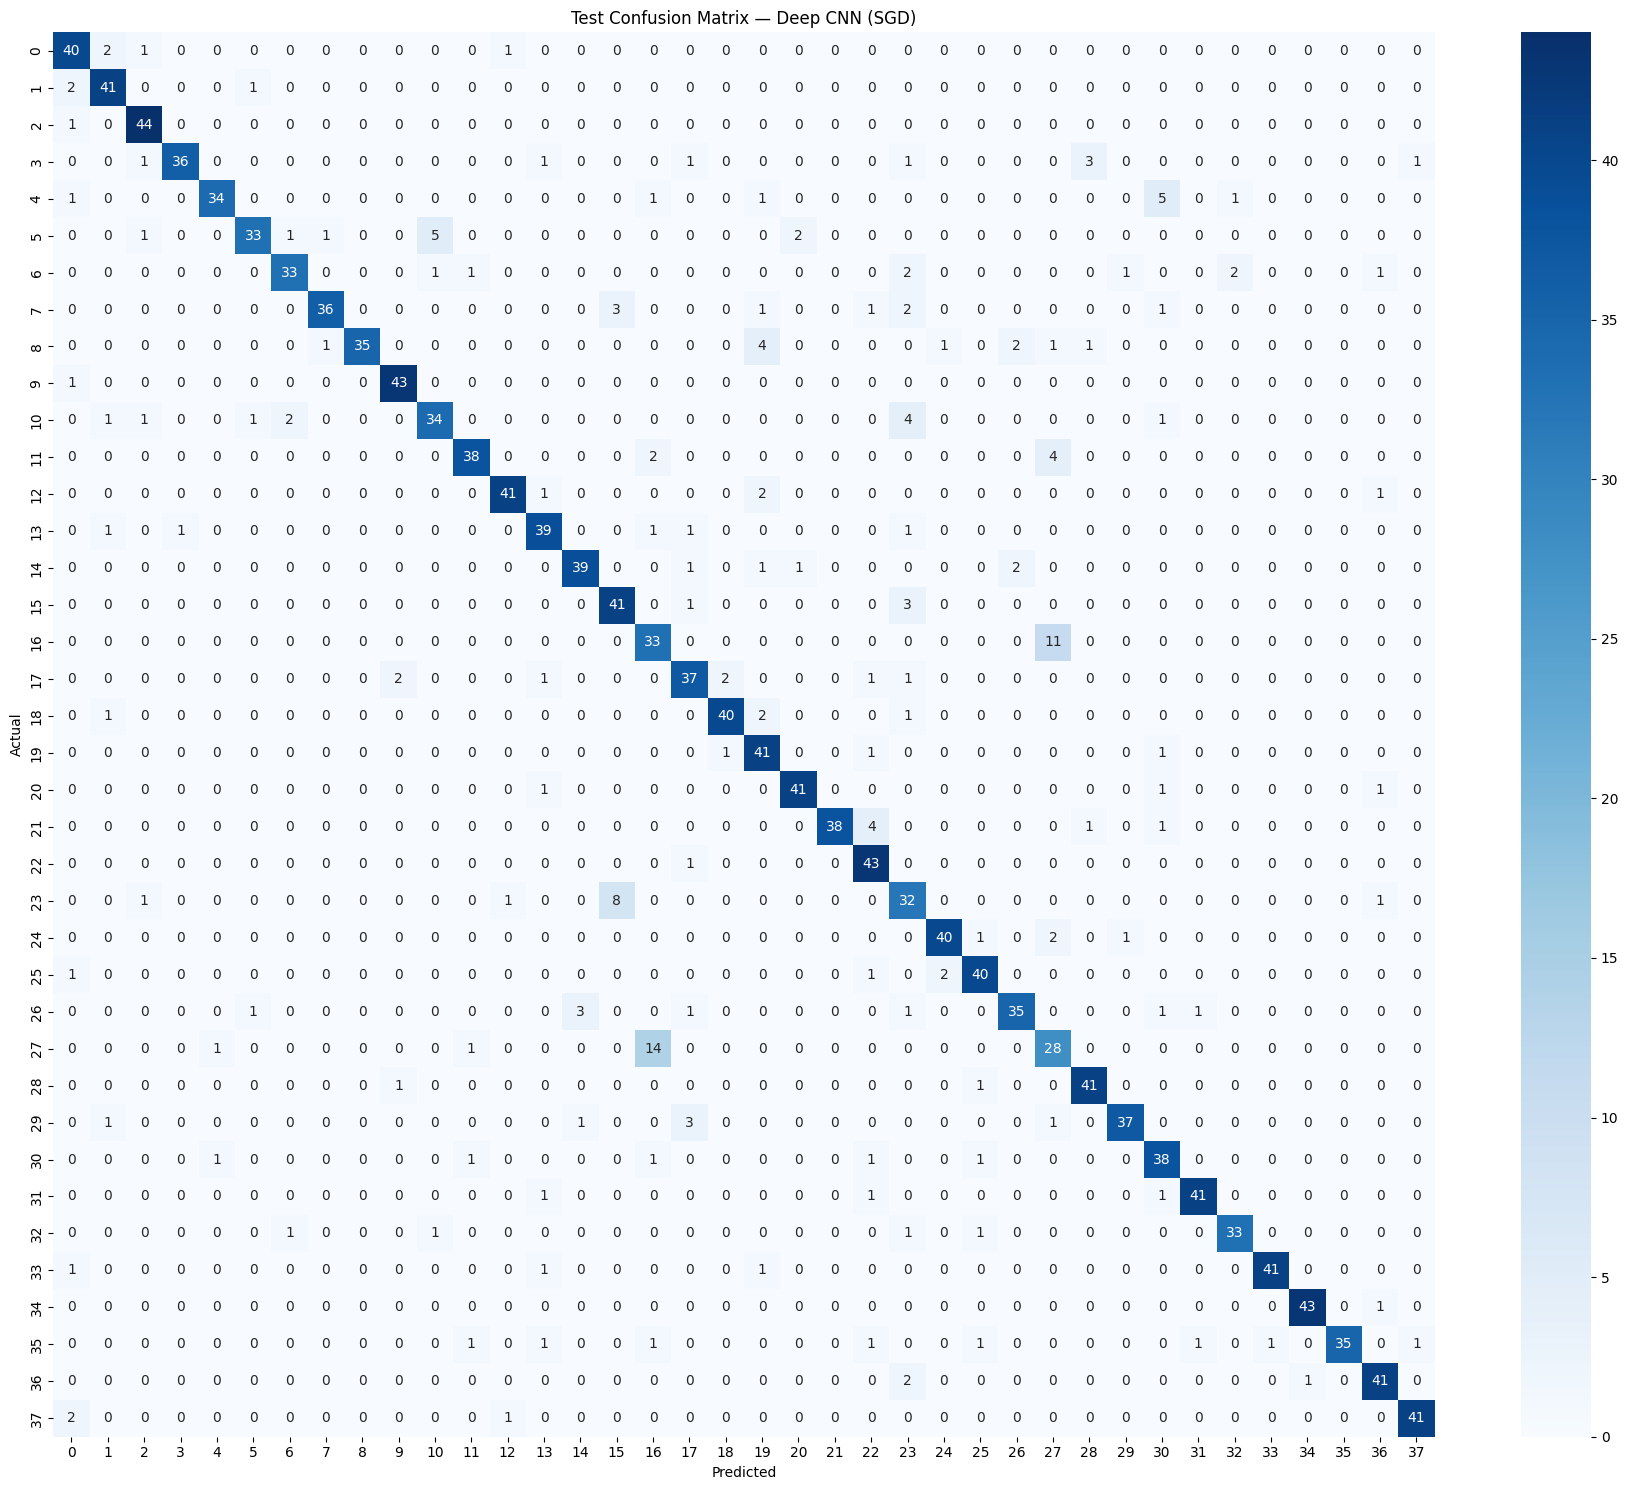

In [ ]:
sgd_test_acc, sgd_test_loss = evaluate_on_test(
    deep_model_sgd, test_data, class_names, model_label="Deep CNN (SGD)"
)

---
## 12. Ablation Study — Remove Dropout
### 12.1 Model without Dropout

• Remove one component (e.g., dropout or batch normalization).

In [ ]:
deep_model_no_dropout = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

deep_model_no_dropout.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

start = time.time()

history_no_dropout = deep_model_no_dropout.fit(
    train_data,
    validation_data=val_data,
    epochs=30
)

nodropout_time = time.time() - start
print(f"No-Dropout Training Time: {nodropout_time:.2f} seconds")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
236/236 ━━━━━━━━━━━━━━━━━━━━ 44s 174ms/step - accuracy: 0.0571 - loss: 3.6055 - val_accuracy: 0.1571 - val_loss: 3.2632
Epoch 2/30
236/236 ━━━━━━━━━━━━━━━━━━━━ 38s 162ms/step - accuracy: 0.1777 - loss: 3.0891 - val_accuracy: 0.2785 - val_loss: 2.7329
Epoch 3/30
236/236 ━━━━━━━━━━━━━━━━━━━━ 38s 162ms/step - accuracy: 0.2771 - loss: 2.6388 - val_accuracy: 0.3648 - val_loss: 2.3289
Epoch 4/30
236/236 ━━━━━━━━━━━━━━━━━━━━ 38s 159ms/step - accuracy: 0.3646 - loss: 2.2621 - val_accuracy: 0.4387 - val_loss: 1.9879
Epoch 5/30
236/236 ━━━━━━━━━━━━━━━━━━━━ 38s 159ms/step - accuracy: 0.4299 - loss: 1.9934 - val_accuracy: 0.4937 - val_loss: 1.7931
Epoch 6/30
236/236 ━━━━━━━━━━━━━━━━━━━━ 39s 163ms/step - accuracy: 0.4839 - loss: 1.7647 - val_accuracy: 0.5350 - val_loss: 1.6290
Epoch 7/30
236/236 ━━━━━━━━━━━━━━━━━━━━ 39s 166ms/step - accuracy: 0.5356 - loss: 1.6031 - val_accuracy: 0.5519 - val_loss: 1.5367
Epoch 8/30
236/236 ━━━━━━━━━━━━━━━━━━━━ 39s 163ms/step - accuracy: 0.5656 - loss: 1

• Analyze how performance changes.

The ablation study removes Dropout from deep learning model to isolate its contribution. Without dropout, the model's training accuracy increases but validation data decreases that results in overfitting.

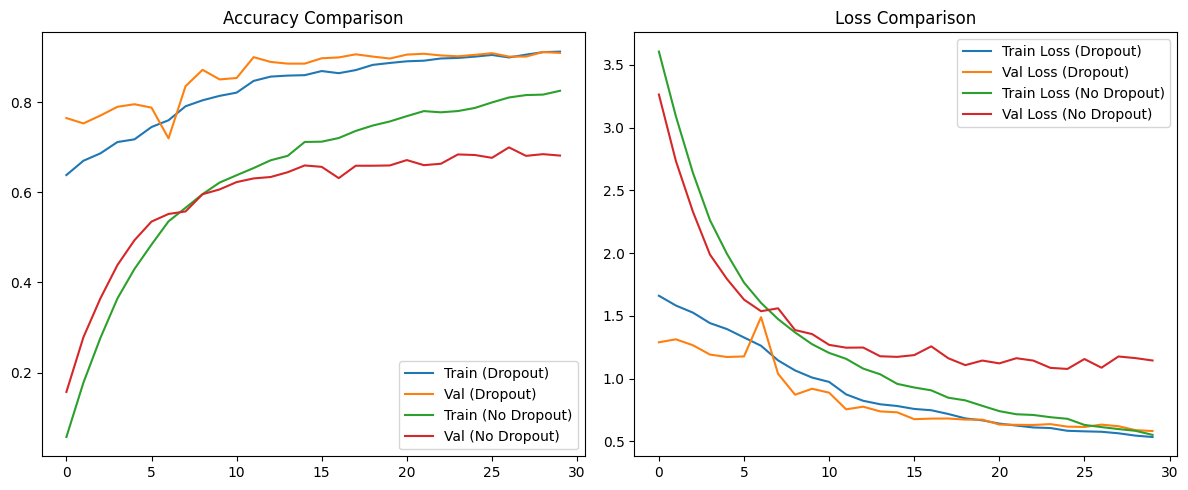

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_deep.history['accuracy'],           label='Train (Dropout)')
plt.plot(history_deep.history['val_accuracy'],       label='Val (Dropout)')
plt.plot(history_no_dropout.history['accuracy'],     label='Train (No Dropout)')
plt.plot(history_no_dropout.history['val_accuracy'], label='Val (No Dropout)')
plt.title("Accuracy Comparison")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_deep.history['loss'],           label='Train Loss (Dropout)')
plt.plot(history_deep.history['val_loss'],       label='Val Loss (Dropout)')
plt.plot(history_no_dropout.history['loss'],     label='Train Loss (No Dropout)')
plt.plot(history_no_dropout.history['val_loss'], label='Val Loss (No Dropout)')
plt.title("Loss Comparison")
plt.legend()

plt.tight_layout()
plt.show()

no_dropout_val_acc = history_no_dropout.history['val_accuracy'][-1]

### 12.3 Test Set Evaluation — No Dropout

52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step
  TEST SET RESULTS — Deep CNN (No Dropout)
  Test Accuracy : 0.6846
  Test Loss     : 1.2145
              precision    recall  f1-score   support

           0     0.8000    0.6364    0.7089        44
           1     0.8810    0.8409    0.8605        44
          10     0.8333    0.7778    0.8046        45
          11     0.8378    0.7045    0.7654        44
          12     0.5849    0.7209    0.6458        43
          13     0.7429    0.6047    0.6667        43
          14     0.5938    0.4634    0.5205        41
          15     0.5227    0.5227    0.5227        44
          16     0.6923    0.8000    0.7423        45
          17     0.6429    0.8182    0.7200        44
          18     0.5625    0.6136    0.5870        44
          19     0.5000    0.5227    0.5111        44
           2     0.7347    0.8000    0.7660        45
          20     0.7500    0.7500    0.7500        44
          21     0.7447    0.7955    0.7692        44
  

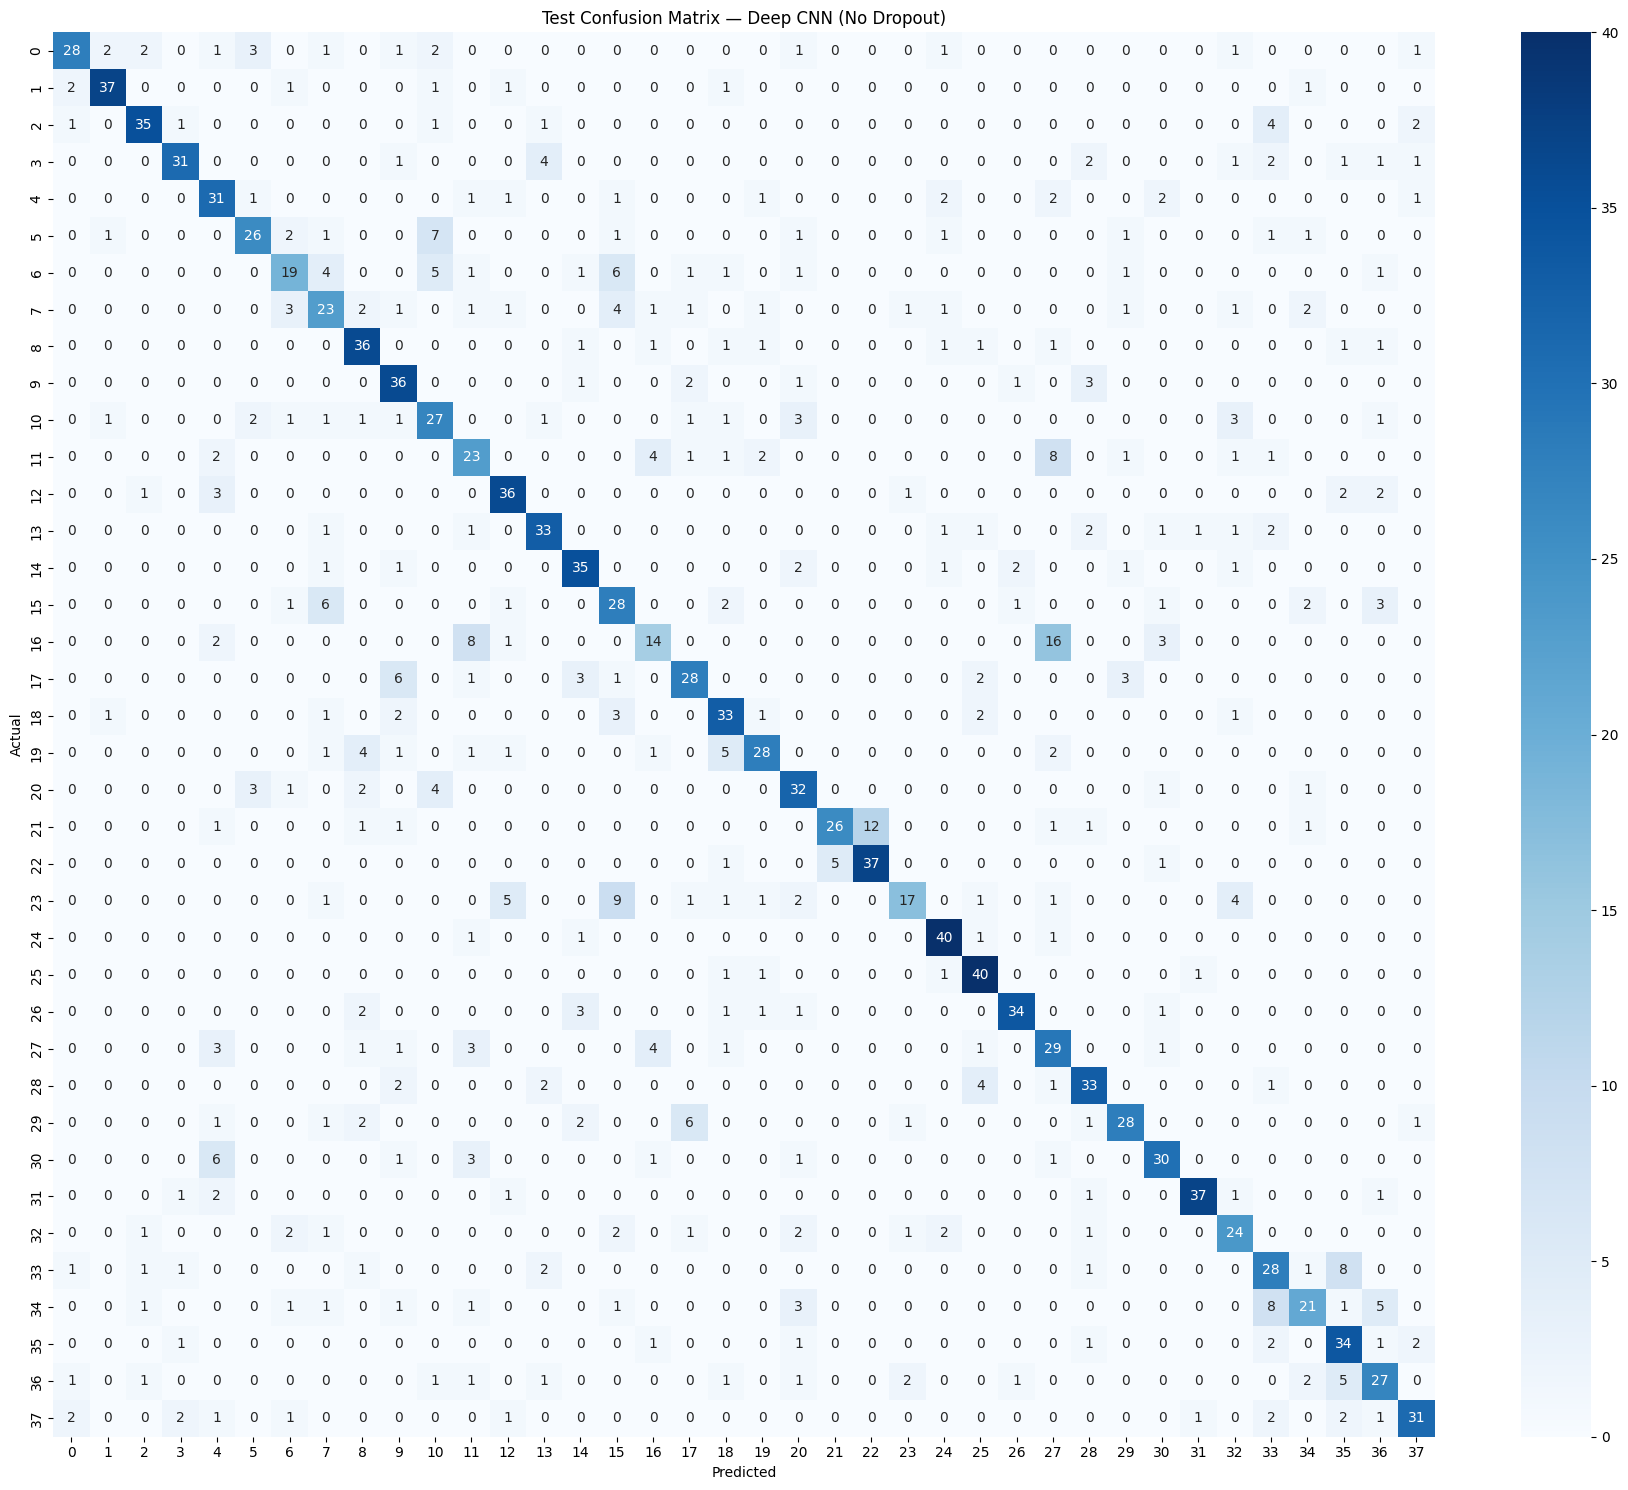

In [ ]:
no_dropout_test_acc, no_dropout_test_loss = evaluate_on_test(
    deep_model_no_dropout, test_data, class_names, model_label="Deep CNN (No Dropout)"
)

#### 5. Challenges and Observations:

• Discuss any difficulties faced, such as overfitting and underfitting.

- Difficulties faced are :
1. Overfitting in the baseline
2. Class confusion in similar images
3. Long training time
4. Learning rate sensitivity for SGD.

• Report the total training time for deeper architecture.

In [ ]:
print(f"Baseline Model Training Time: {training_time:.2f} seconds")
print(f"Deeper Model (Adam) Training Time: {deep_training_time:.2f} seconds")
print(f"Deeper Model (SGD) Training Time: {sgd_training_time:.2f} seconds")
print(f"Ablation Model (No Dropout) Training Time: {nodropout_time:.2f} seconds")

Baseline Model Training Time: 850.79 seconds
Deeper Model (Adam) Training Time: 1319.03 seconds
Deeper Model (SGD) Training Time: 1300.29 seconds
Ablation Model (No Dropout) Training Time: 1166.30 seconds


• Mention if hardware acceleration (e.g. Google Colab, with GPU/TPU was used

-Google Colab with T4 GPU was used for all training.

## 2.6 Part B: Fine-Tuning a Pre-Trained Model (Transfer Learning).

 ### 2.6.1 Loading and Adapting a Pre- Trained Model:

• Select an appropriate pre- trained CNN model (e.g. VGG, ResNet, Incpetion) based on the character
stics of your dataset.

- MobileNetV2 was selected as the pre-trained model for following reasons:

1. Effeciency
2. Moderate complex images
3. Speed


• Load the pre- trained model using keras.

In [ ]:
IMG_SIZE_TL = (224, 224)

tl_train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=False
)
tl_val_test_gen = ImageDataGenerator(rescale=1./255)

tl_train_data = tl_train_gen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE_TL,
    batch_size=BATCH_SIZE, class_mode='categorical',
    shuffle=True, seed=SEED
)

tl_val_data = tl_val_test_gen.flow_from_directory(
    VAL_DIR, target_size=IMG_SIZE_TL,
    batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False
)

tl_test_data = tl_val_test_gen.flow_from_directory(
    TEST_DIR, target_size=IMG_SIZE_TL,
    batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False
)

print(f"TL Train: {tl_train_data.samples} | Val: {tl_val_data.samples} | Test: {tl_test_data.samples}")

Found 7536 images belonging to 38 classes.
Found 1598 images belonging to 38 classes.
Found 1658 images belonging to 38 classes.
TL Train: 7536 | Val: 1598 | Test: 1658


• Modify the model architecture to fit your specific classification task.

– Remove the original fully connected layers.

– Add a new dense layers tailored to your dataset’s number of classes.

• Choose whether to freeze certain layers or fine- tune the entire model based on your dataset size and
computational constraints.

In the feature extraction phase, all MobileNetV2 layer are froxe and only the newly added classification layers are trained. It is done because of following reasons:

1. Dataset size: The dataset is small compared to ImageNet avoiding catastrophic forgetting.
2. The source and target dataset both involves real-worls photography.

### 2.6.2 Model Training and Fine- Tuning:

In [ ]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)
base_model.trainable = False

transfer_model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

transfer_model.compile(
    optimizer=Adam(),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

transfer_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 38)             │         9,766 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,595,686 (9.90 MB)

 Trainable params: 337,702 (1.29 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
start = time.time()

history_transfer = transfer_model.fit(
    tl_train_data,
    validation_data=tl_val_data,
    epochs=10
)

transfer_training_time = time.time() - start
print(f"Transfer Learning Training Time: {transfer_training_time:.2f} seconds")

Epoch 1/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 145s 532ms/step - accuracy: 0.2625 - loss: 2.6268 - val_accuracy: 0.6114 - val_loss: 1.4382
Epoch 2/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 91s 387ms/step - accuracy: 0.4780 - loss: 1.6641 - val_accuracy: 0.6777 - val_loss: 1.1000
Epoch 3/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 93s 393ms/step - accuracy: 0.5573 - loss: 1.3715 - val_accuracy: 0.7378 - val_loss: 0.9097
Epoch 4/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 92s 392ms/step - accuracy: 0.6064 - loss: 1.2247 - val_accuracy: 0.7478 - val_loss: 0.8389
Epoch 5/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 93s 394ms/step - accuracy: 0.6375 - loss: 1.1273 - val_accuracy: 0.7553 - val_loss: 0.7710
Epoch 6/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 93s 395ms/step - accuracy: 0.6421 - loss: 1.0817 - val_accuracy: 0.7741 - val_loss: 0.7537
Epoch 7/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 92s 392ms/step - accuracy: 0.6750 - loss: 1.0038 - val_accuracy: 0.7722 - val_loss: 0.7253
Epoch 8/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 92s 391ms/step - accuracy: 0.6612 - loss: 

52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step
  TEST SET RESULTS — MobileNetV2 (Feature Extraction)
  Test Accuracy : 0.8040
  Test Loss     : 0.6614
              precision    recall  f1-score   support

           0     0.7800    0.8864    0.8298        44
           1     0.8864    0.8864    0.8864        44
          10     0.8913    0.9111    0.9011        45
          11     0.8269    0.9773    0.8958        44
          12     0.9737    0.8605    0.9136        43
          13     1.0000    0.6279    0.7714        43
          14     0.6034    0.8537    0.7071        41
          15     1.0000    0.4545    0.6250        44
          16     0.9737    0.8222    0.8916        45
          17     0.9677    0.6818    0.8000        44
          18     0.6341    0.5909    0.6118        44
          19     1.0000    0.5000    0.6667        44
           2     0.9545    0.9333    0.9438        45
          20     0.9744    0.8636    0.9157        44
          21     0.9697    0.7273    0.8312  

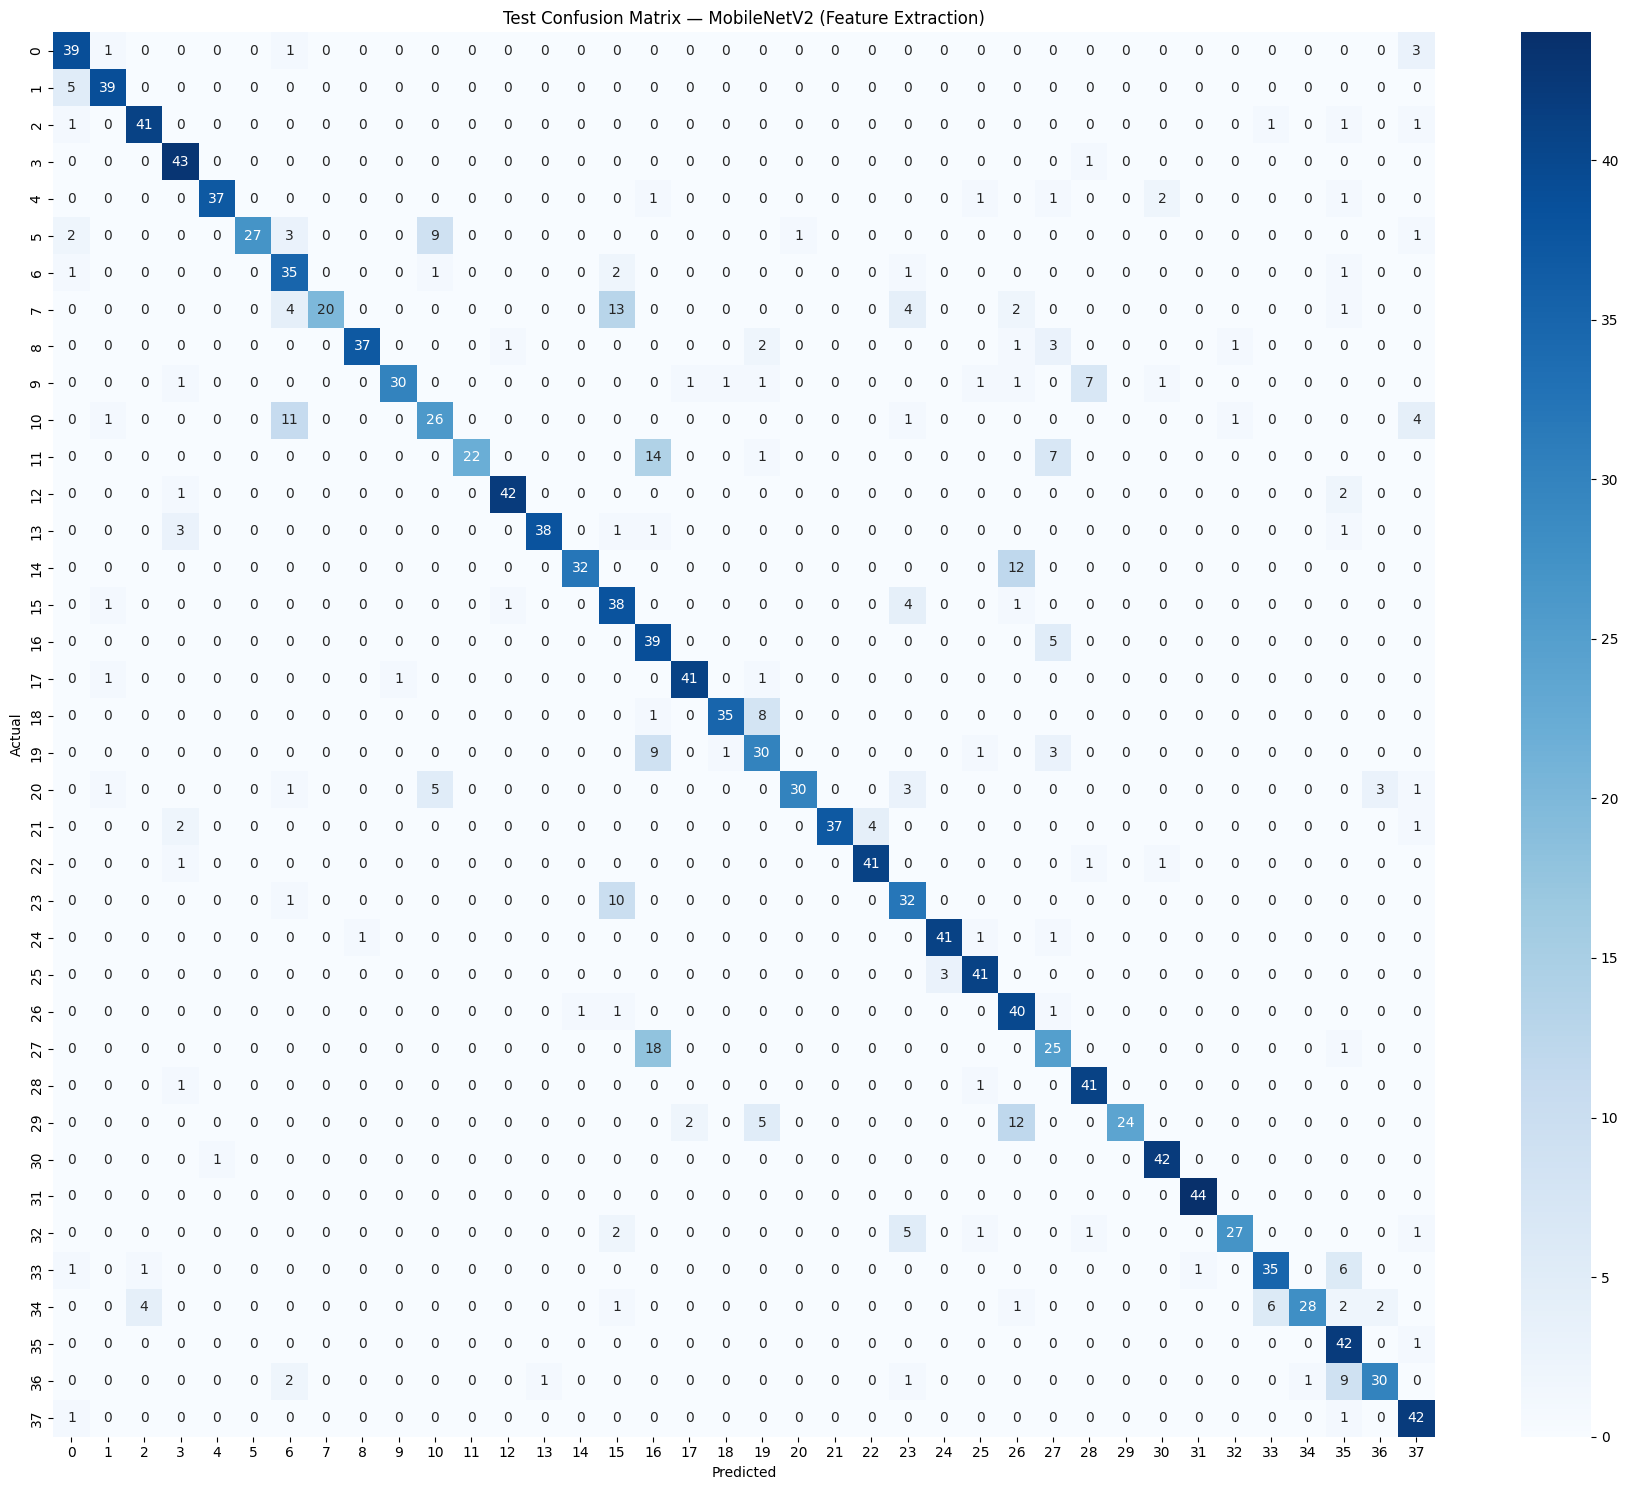

In [ ]:
tl_test_acc, tl_test_loss = evaluate_on_test(
    transfer_model, tl_test_data, class_names,
    model_label="MobileNetV2 (Feature Extraction)"
)

• Fine- Tuning:

– Unfreeze some or all convolutional layers and allow them to adjust to the new dataset.

– This approach requires a lower learning rate to avoid overfitting and catastrophic forgetting.

###Phase 2 — Fine-Tuning (Unfreeze Last 20 Layers)

In [ ]:
base_model.trainable = True

# Freeze early layers, unfreeze last 50
for layer in base_model.layers[:-50]:
    layer.trainable = False

transfer_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7)

history_fine = transfer_model.fit(
    tl_train_data,
    validation_data=tl_val_data,
    epochs=20
)

fine_val_acc = max(history_fine.history['val_accuracy'])

Epoch 1/20
236/236 ━━━━━━━━━━━━━━━━━━━━ 121s 451ms/step - accuracy: 0.8551 - loss: 0.4221 - val_accuracy: 0.8511 - val_loss: 0.4681
Epoch 2/20
236/236 ━━━━━━━━━━━━━━━━━━━━ 94s 397ms/step - accuracy: 0.8798 - loss: 0.3550 - val_accuracy: 0.8611 - val_loss: 0.4357
Epoch 3/20
236/236 ━━━━━━━━━━━━━━━━━━━━ 95s 402ms/step - accuracy: 0.8875 - loss: 0.3401 - val_accuracy: 0.8523 - val_loss: 0.4831
Epoch 4/20
236/236 ━━━━━━━━━━━━━━━━━━━━ 94s 397ms/step - accuracy: 0.8972 - loss: 0.3021 - val_accuracy: 0.8648 - val_loss: 0.4465
Epoch 5/20
236/236 ━━━━━━━━━━━━━━━━━━━━ 93s 393ms/step - accuracy: 0.9023 - loss: 0.2932 - val_accuracy: 0.8899 - val_loss: 0.3718
Epoch 6/20
236/236 ━━━━━━━━━━━━━━━━━━━━ 95s 401ms/step - accuracy: 0.9163 - loss: 0.2564 - val_accuracy: 0.8717 - val_loss: 0.4358
Epoch 7/20
236/236 ━━━━━━━━━━━━━━━━━━━━ 91s 384ms/step - accuracy: 0.9187 - loss: 0.2453 - val_accuracy: 0.8955 - val_loss: 0.3325
Epoch 8/20
236/236 ━━━━━━━━━━━━━━━━━━━━ 92s 391ms/step - accuracy: 0.9279 - loss: 

52/52 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step
  TEST SET RESULTS — MobileNetV2 (Fine-Tuned)
  Test Accuracy : 0.9041
  Test Loss     : 0.3453
              precision    recall  f1-score   support

           0     0.7593    0.9318    0.8367        44
           1     0.8431    0.9773    0.9053        44
          10     0.8776    0.9556    0.9149        45
          11     0.8431    0.9773    0.9053        44
          12     1.0000    0.9070    0.9512        43
          13     0.8718    0.7907    0.8293        43
          14     0.8140    0.8537    0.8333        41
          15     1.0000    0.6818    0.8108        44
          16     0.9762    0.9111    0.9425        45
          17     0.9348    0.9773    0.9556        44
          18     0.7600    0.8636    0.8085        44
          19     0.9487    0.8409    0.8916        44
           2     0.9756    0.8889    0.9302        45
          20     0.9524    0.9091    0.9302        44
          21     0.9333    0.9545    0.9438        

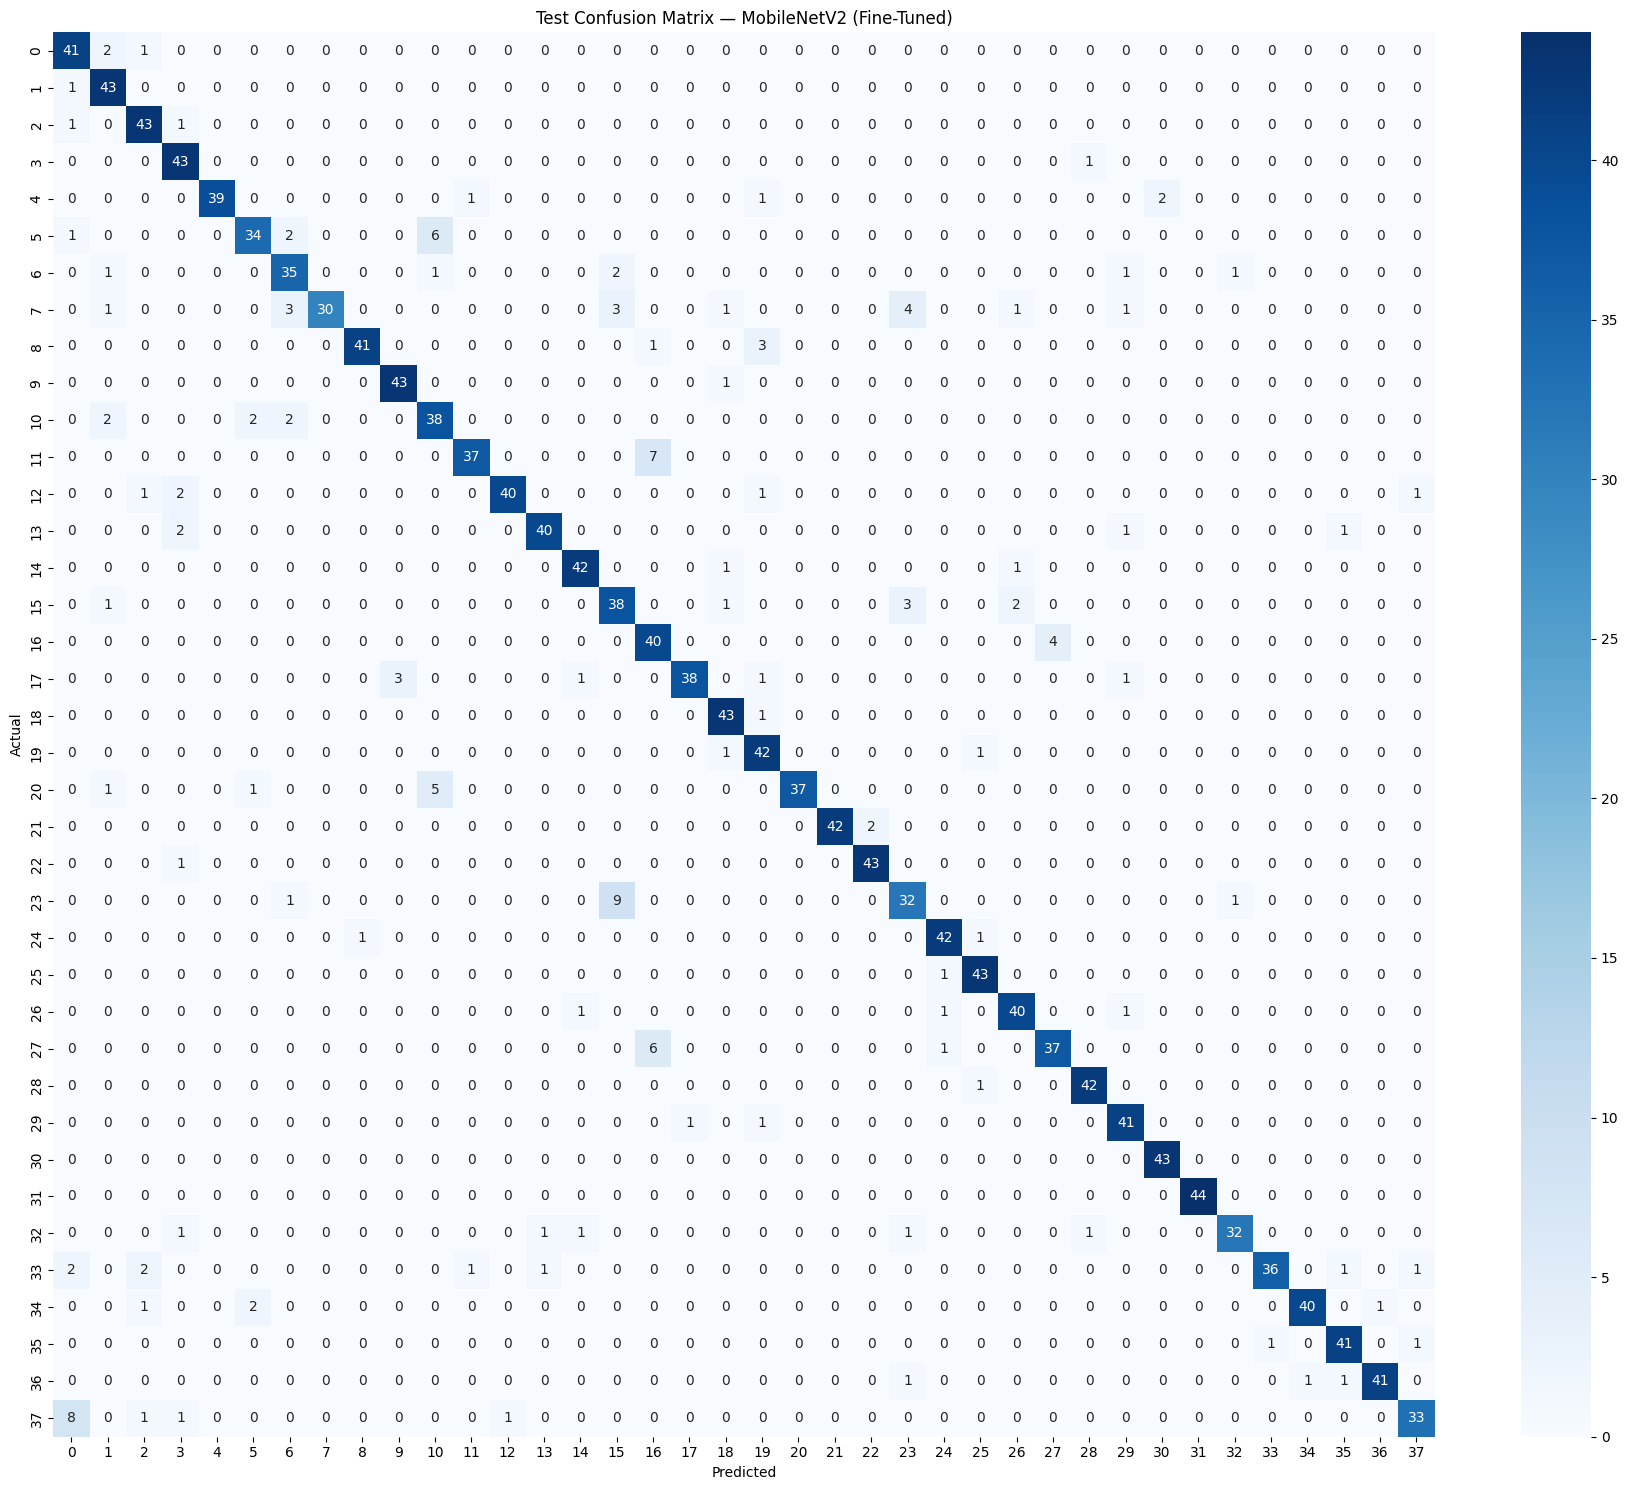

In [ ]:
fine_test_acc, fine_test_loss = evaluate_on_test(
    transfer_model, tl_test_data, class_names,
    model_label="MobileNetV2 (Fine-Tuned)"
)


### Final Comparison — All Models
####  14.1 Validation vs Test Accuracy

In [ ]:
print("\n" + "="*65)
print(f"{'MODEL':<35} {'VAL ACC':>10} {'TEST ACC':>10}")
print("="*65)

rows = [
    ("Baseline CNN",                  baseline_val_acc,   baseline_test_acc),
    ("Deep CNN (Adam)",               deep_val_acc,       deep_test_acc),
    ("Deep CNN (SGD)",                sgd_val_acc,        sgd_test_acc),
    ("Deep CNN (No Dropout)",         no_dropout_val_acc, no_dropout_test_acc),
    ("MobileNetV2 (Feature Extrac.)", tl_test_acc,        tl_test_acc),
    ("MobileNetV2 (Fine-Tuned)",      fine_val_acc,       fine_test_acc),
]

for name, val_acc, test_acc in rows:
    print(f"{name:<35} {val_acc:>10.4f} {test_acc:>10.4f}")



MODEL                                  VAL ACC   TEST ACC
Baseline CNN                            0.8060     0.7871
Deep CNN (Adam)                         0.9111     0.9168
Deep CNN (SGD)                          0.8661     0.8721
Deep CNN (No Dropout)                   0.6815     0.6846
MobileNetV2 (Feature Extrac.)           0.8040     0.8040
MobileNetV2 (Fine-Tuned)                0.9186     0.9041


### 14.2 Bar Chart — Validation vs Test Accuracy

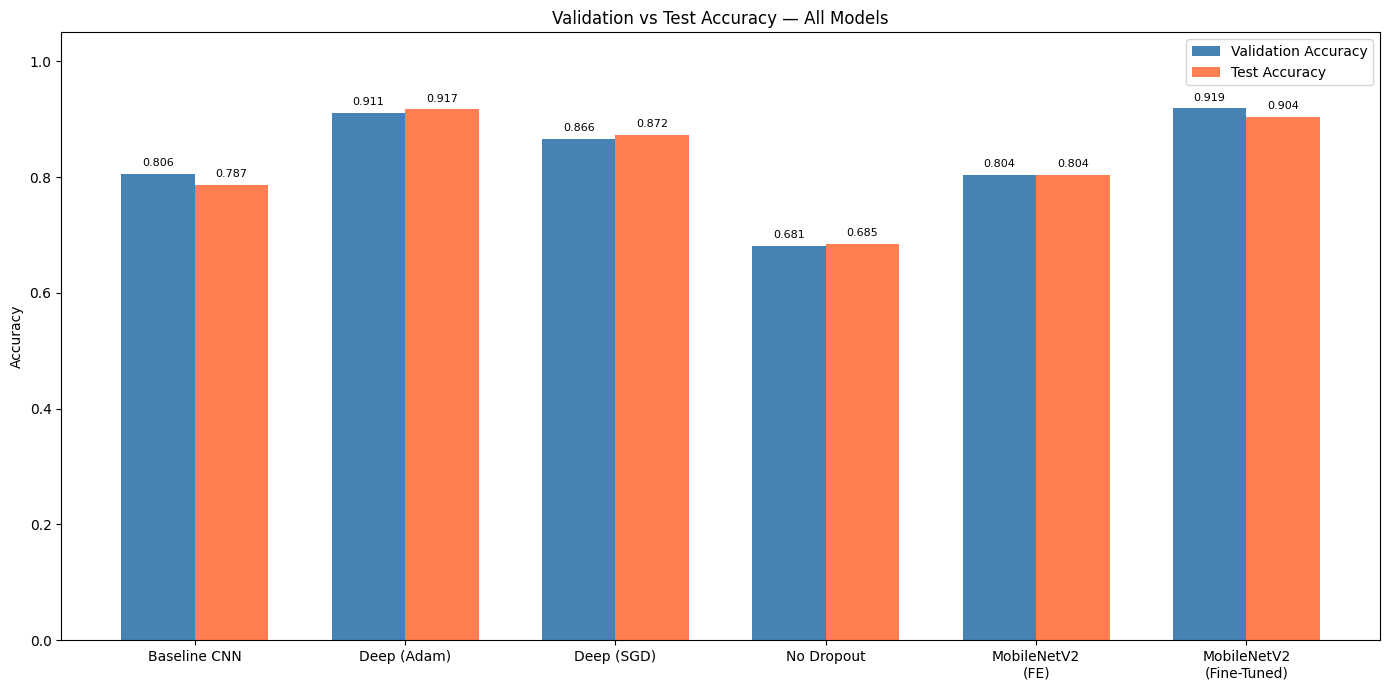

In [ ]:
model_names = [
    "Baseline CNN",
    "Deep (Adam)",
    "Deep (SGD)",
    "No Dropout",
    "MobileNetV2\n(FE)",
    "MobileNetV2\n(Fine-Tuned)"
]

val_accs  = [baseline_val_acc,  deep_val_acc,  sgd_val_acc,
             no_dropout_val_acc, tl_test_acc,   fine_val_acc]
test_accs = [baseline_test_acc, deep_test_acc, sgd_test_acc,
             no_dropout_test_acc, tl_test_acc,  fine_test_acc]

x = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 7))
bars1 = ax.bar(x - width/2, val_accs,  width, label='Validation Accuracy', color='steelblue')
bars2 = ax.bar(x + width/2, test_accs, width, label='Test Accuracy',       color='coral')

ax.set_ylabel('Accuracy')
ax.set_title('Validation vs Test Accuracy — All Models')
ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.set_ylim(0, 1.05)
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

### 14.3 Training Time Comparison

In [ ]:
print("\nTRAINING TIMES")
print(f"Baseline CNN              : {training_time:.2f} sec")
print(f"Deep CNN (Adam)           : {deep_training_time:.2f} sec")
print(f"Deep CNN (SGD)            : {sgd_training_time:.2f} sec")
print(f"No Dropout Ablation       : {nodropout_time:.2f} sec")
print(f"MobileNetV2 (Feature Ext.): {transfer_training_time:.2f} sec")


TRAINING TIMES
Baseline CNN              : 850.79 sec
Deep CNN (Adam)           : 1319.03 sec
Deep CNN (SGD)            : 1300.29 sec
No Dropout Ablation       : 1166.30 sec
MobileNetV2 (Feature Ext.): 977.42 sec
